# Jad Hdeife & Ahmad El Hariri - UK Road Safety Dataset

# 1. Introduction
This project aims to analyze the UK Road Safety dataset and build a machine learning model to predict collision severity. The work is based on three related datasets: collisions, vehicles, and casualties. These datasets are merged to create a richer analytical table that captures collision-level, vehicle-level, and casualty-level information in one place.

## 1.1 Project Objective
The objective of this project is to predict `collision_severity`, which represents the severity level of a road collision. This is a multiclass classification problem with three outcome classes: Fatal, Serious, and Slight.

This problem is important because collision severity is one of the most meaningful road safety outcomes. Understanding the factors associated with severe collisions can help identify risky conditions and support better prevention strategies, traffic policies, and safety interventions.

The final analysis is performed on a merged dataset created from the collision, vehicle, and casualty tables. Therefore, the unit of analysis in this project is a merged collision–vehicle–casualty record rather than a pure collision-only row.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

# Load datasets
collision_path = "/content/drive/MyDrive/CMPS 262 Project/dft-road-casualty-statistics-collision-2023.csv"
vehicle_path = "/content/drive/MyDrive/CMPS 262 Project/dft-road-casualty-statistics-vehicle-2023.csv"
casualty_path = "/content/drive/MyDrive/CMPS 262 Project/dft-road-casualty-statistics-casualty-2023.csv"

df_collision = pd.read_csv(collision_path, low_memory=False)
df_vehicle = pd.read_csv(vehicle_path, low_memory=False)
df_casualty = pd.read_csv(casualty_path, low_memory=False)

print("Collision shape:", df_collision.shape)
print("Vehicle shape:", df_vehicle.shape)
print("Casualty shape:", df_casualty.shape)

Collision shape: (104258, 44)
Vehicle shape: (189815, 32)
Casualty shape: (132977, 23)


In [4]:
# Merge datasets
df_merged = df_collision.merge(
    df_vehicle,
    on="collision_index",
    how="left",
    suffixes=("_collision", "_vehicle")
)

df_final = df_merged.merge(
    df_casualty,
    on=["collision_index", "vehicle_reference"],
    how="left",
    suffixes=("", "_casualty")
)

print("Merged dataset shape:", df_final.shape)

Merged dataset shape: (207816, 96)


In [5]:
# Summary table for introduction
summary_df = pd.DataFrame({
    "Dataset": ["Collision", "Vehicle", "Casualty", "Final merged"],
    "Rows": [df_collision.shape[0], df_vehicle.shape[0], df_casualty.shape[0], df_final.shape[0]],
    "Columns": [df_collision.shape[1], df_vehicle.shape[1], df_casualty.shape[1], df_final.shape[1]]
})

summary_df

,Dataset,Rows,Columns
0,Collision,104258,44
1,Vehicle,189815,32
2,Casualty,132977,23
3,Final merged,207816,96


After merge, the number of features droped from 99 to 96 because merging is done on collision_index and vehicle_reference; they are repeated features in the 3 documents and for that they were dropped.

### 1 Identifier and Time Features

| Feature | Definition | Type |
|---|---|---|
| `collision_index` | Unique identifier for each collision; used to link collision, vehicle, and casualty records | ID / string |
| `collision_year_collision` | Year in which the collision occurred (collision table version) | Integer |
| `collision_ref_no_collision` | Police reference number for the collision within that year (collision table version) | String |
| `date` | Calendar date of the collision | Date |
| `day_of_week` | Day of the week on which the collision occurred | Categorical (coded) |
| `time` | Time of day when the collision occurred | Time |
| `collision_year_vehicle` | Year of the linked collision record in the vehicle table | Integer |
| `collision_ref_no_vehicle` | Police collision reference number in the vehicle table | String |
| `collision_year` | Year of the linked collision record in the casualty table | Integer |
| `collision_ref_no` | Police collision reference number in the casualty table | String |
| `vehicle_reference` | Reference number identifying a vehicle within a collision | Integer |
| `casualty_reference` | Reference number identifying a casualty within a collision | Integer |

### 2 Location and Administrative Features

| Feature | Definition | Type |
|---|---|---|
| `location_easting_osgr` | Easting coordinate of the collision in the British National Grid | Numeric |
| `location_northing_osgr` | Northing coordinate of the collision in the British National Grid | Numeric |
| `longitude` | Geographic longitude of the collision location | Float |
| `latitude` | Geographic latitude of the collision location | Float |
| `police_force` | Police force area that recorded the collision | Categorical (coded) |
| `local_authority_district` | Local authority district code for the collision area | Categorical (coded) |
| `local_authority_ons_district` | ONS district code for the local authority area | Categorical (coded/string) |
| `local_authority_highway` | Highway authority code for the collision location | Categorical (coded/string) |
| `local_authority_highway_current` | Updated highway authority code using current boundaries | Categorical (coded/string) |
| `lsoa_of_accident_location` | Lower Layer Super Output Area code of the collision location | Categorical (area code) |
| `lsoa_of_driver` | Lower Layer Super Output Area code of the driver’s residence | Categorical (area code) |
| `lsoa_of_casualty` | Lower Layer Super Output Area code of the casualty’s residence | Categorical (area code) |

### 3 Collision, Road, and Environment Features

| Feature | Definition | Type |
|---|---|---|
| `collision_severity` | Overall severity level assigned to the collision | Categorical (coded) |
| `number_of_vehicles` | Number of vehicles involved in the collision | Integer |
| `number_of_casualties` | Number of casualties resulting from the collision | Integer |
| `first_road_class` | Class of the main road on which the collision happened | Categorical (coded) |
| `first_road_number` | Road number of the main road | Integer |
| `road_type` | Type of road where the collision occurred | Categorical (coded) |
| `speed_limit` | Posted speed limit at the collision location | Categorical (coded) |
| `junction_detail_historic` | Historic coding for the type/detail of junction | Categorical (coded) |
| `junction_detail` | Current coding for the type/detail of junction | Categorical (coded) |
| `junction_control` | Type of control present at the junction | Categorical (coded) |
| `second_road_class` | Class of the secondary road at the junction, if applicable | Categorical (coded) |
| `second_road_number` | Road number of the secondary road at the junction, if applicable | Integer |
| `pedestrian_crossing_human_control_historic` | Historic coding for human-controlled pedestrian crossing facilities | Categorical (coded) |
| `pedestrian_crossing_physical_facilities_historic` | Historic coding for physical pedestrian crossing facilities | Categorical (coded) |
| `pedestrian_crossing` | Current coding for pedestrian crossing facilities at the site | Categorical (coded) |
| `light_conditions` | Lighting conditions at the time of collision | Categorical (coded) |
| `weather_conditions` | Weather conditions at the time of collision | Categorical (coded) |
| `road_surface_conditions` | Condition of the road surface at the time of collision | Categorical (coded) |
| `special_conditions_at_site` | Special temporary or unusual conditions at the site | Categorical (coded) |
| `carriageway_hazards_historic` | Historic coding for hazards present on the carriageway | Categorical (coded) |
| `carriageway_hazards` | Current coding for hazards present on the carriageway | Categorical (coded) |
| `urban_or_rural_area` | Indicator of whether the collision occurred in an urban or rural area | Categorical (coded) |
| `did_police_officer_attend_scene_of_accident` | Whether a police officer attended the collision scene | Categorical (coded) |
| `trunk_road_flag` | Indicator of whether the road is part of the trunk road network | Categorical (coded) |
| `enhanced_severity_collision` | Enhanced or revised collision severity classification | Categorical (coded) |
| `collision_injury_based` | Injury-based derived collision severity indicator | Categorical (derived) |
| `collision_adjusted_severity_serious` | Derived probability or adjusted indicator for serious collision severity | Float |
| `collision_adjusted_severity_slight` | Derived probability or adjusted indicator for slight collision severity | Float |

### 4 Vehicle and Driver Features

| Feature | Definition | Type |
|---|---|---|
| `vehicle_type` | Type/category of vehicle involved | Categorical (coded) |
| `towing_and_articulation` | Towing or articulation status of the vehicle | Categorical (coded) |
| `vehicle_manoeuvre_historic` | Historic coding for the vehicle manoeuvre before impact | Categorical (coded) |
| `vehicle_manoeuvre` | Current coding for the vehicle manoeuvre before impact | Categorical (coded) |
| `vehicle_direction_from` | Direction from which the vehicle was travelling | Categorical (coded) |
| `vehicle_direction_to` | Direction towards which the vehicle was travelling | Categorical (coded) |
| `vehicle_location_restricted_lane_historic` | Historic coding for vehicle position in a restricted lane | Categorical (coded) |
| `vehicle_location_restricted_lane` | Current coding for vehicle position in a restricted lane | Categorical (coded) |
| `junction_location` | Vehicle’s location relative to a junction | Categorical (coded) |
| `skidding_and_overturning` | Whether the vehicle skidded or overturned | Categorical (coded) |
| `hit_object_in_carriageway` | Whether the vehicle hit an object on the carriageway | Categorical (coded) |
| `vehicle_leaving_carriageway` | Whether and how the vehicle left the carriageway | Categorical (coded) |
| `hit_object_off_carriageway` | Whether the vehicle hit an object after leaving the carriageway | Categorical (coded) |
| `first_point_of_impact` | First point of impact on the vehicle | Categorical (coded) |
| `vehicle_left_hand_drive` | Whether the vehicle is left-hand drive | Categorical (coded) |
| `journey_purpose_of_driver_historic` | Historic coding for the driver’s journey purpose | Categorical (coded) |
| `journey_purpose_of_driver` | Current coding for the driver’s journey purpose | Categorical (coded) |
| `sex_of_driver` | Sex of the driver | Categorical (coded) |
| `age_of_driver` | Age of the driver in years | Integer |
| `age_band_of_driver` | Age band of the driver | Categorical (coded) |
| `engine_capacity_cc` | Engine capacity of the vehicle in cubic centimetres | Integer |
| `propulsion_code` | Type of propulsion or fuel system used by the vehicle | Categorical (coded) |
| `age_of_vehicle` | Age of the vehicle in years | Integer |
| `generic_make_model` | Generic make/model grouping of the vehicle | String |
| `driver_imd_decile` | Driver’s residential deprivation decile (Index of Multiple Deprivation) | Categorical (coded) |
| `escooter_flag` | Indicator of whether the vehicle is an e-scooter | Categorical (coded) |
| `driver_distance_banding` | Band representing journey distance travelled by the driver | Categorical (coded) |

### 5 Casualty Features

| Feature | Definition | Type |
|---|---|---|
| `casualty_class` | Role of the casualty (e.g. driver, passenger, pedestrian) | Categorical (coded) |
| `sex_of_casualty` | Sex of the casualty | Categorical (coded) |
| `age_of_casualty` | Age of the casualty in years | Integer |
| `age_band_of_casualty` | Age band of the casualty | Categorical (coded) |
| `casualty_severity` | Severity of injury suffered by the casualty | Categorical (coded) |
| `pedestrian_location` | Pedestrian’s location at the time of collision | Categorical (coded) |
| `pedestrian_movement` | Pedestrian’s movement at the time of collision | Categorical (coded) |
| `car_passenger` | Type/position of car passenger, if applicable | Categorical (coded) |
| `bus_or_coach_passenger` | Type/position of bus or coach passenger, if applicable | Categorical (coded) |
| `pedestrian_road_maintenance_worker` | Whether the casualty was a road maintenance worker acting as a pedestrian | Categorical (coded) |
| `casualty_type` | Type/category of casualty | Categorical (coded) |
| `casualty_imd_decile` | Casualty’s residential deprivation decile (Index of Multiple Deprivation) | Categorical (coded) |
| `enhanced_casualty_severity` | Enhanced or revised casualty severity classification | Categorical (coded) |
| `casualty_injury_based` | Injury-based derived casualty severity indicator | Categorical (derived) |
| `casualty_adjusted_severity_serious` | Derived probability or adjusted indicator for serious casualty severity | Float |
| `casualty_adjusted_severity_slight` | Derived probability or adjusted indicator for slight casualty severity | Float |
| `casualty_distance_banding` | Band representing distance travelled by the casualty | Categorical (coded) |

In [6]:
# Data type summary for the final merged dataset
dtype_summary = pd.DataFrame(df_final.dtypes.value_counts()).reset_index()
dtype_summary.columns = ["Data Type", "Count"]
dtype_summary

,Data Type,Count
0,int64,58
1,float64,25
2,object,13


In [7]:
from google.colab import files

# Save the dataframe to a CSV file
df_final.to_csv('uk_road_safety_final.csv', index=False)

# Trigger the download to your local machine
files.download('uk_road_safety_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 1.2 Dataset Description
The project uses three CSV files from the UK Road Safety dataset:
- the collision table, which contains collision-level information such as severity, date, time, road type, speed limit, and environmental conditions
- the vehicle table, which contains vehicle- and driver-related information such as vehicle type, manoeuvre, age of driver, propulsion, and vehicle age
- the casualty table, which contains casualty-level information such as casualty class, severity, age, pedestrian-related features, and casualty type

These tables are merged using the dataset keys:
- `collision_index` for collision–vehicle merging
- `collision_index` and `vehicle_reference` for merging casualties into the collision–vehicle table

The final merged table contains mixed feature types, including numerical variables, coded categorical variables, identifiers, and date/time fields.

## 1.3 Project Roadmap
This project is organized into the following stages:

2. Exploratory Data Analysis (EDA) to understand the structure, distributions, missing values, and patterns in the data
3. Data Cleaning to address irrelevant, redundant, sparse, or problematic variables
4. Feature Engineering to create more informative predictors from raw variables
5. Feature Selection using both statistical and model-based methods
6. Model Assumption Checks, especially for logistic regression
7. Machine Learning Modeling using baseline, interpretable, and tree-based classifiers + Model Evaluation using multiple classification metrics and comparison strategies
8. Results and Conclusion to summarize findings, limitations, and future improvements

# 2. Exploratory Data Analysis (EDA)
The goal of this section is to understand the merged dataset before making transformations or modeling decisions. The analysis focuses on data structure, target distribution, missing values, distributions of key numerical features, important categorical variables, and early relationships between predictors and collision severity.

At this stage, the purpose is observation and interpretation, not transformation.

## 2.1 Target Analysis
This subsection examines the class distribution of `collision_severity`. Since the target is categorical and clearly imbalanced, it is important to inspect both counts and proportions before any modeling step.

For readability, the target codes are mapped to their human-readable labels only inside this analysis, without changing the raw dataset.

In [ ]:
duplicate_count = df_final.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 0


Label mappings used only for EDA display (for the plots):

In [ ]:
# Label mappings used only for EDA display
collision_severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

road_type_map = {
    1: "Roundabout",
    2: "One way street",
    3: "Dual carriageway",
    6: "Single carriageway",
    7: "Slip road",
    9: "Unknown",
    12: "One way street / Slip road",
    -1: "Missing / Out of range"
}

weather_conditions_map = {
    1: "Fine no high winds",
    2: "Raining no high winds",
    3: "Snowing no high winds",
    4: "Fine + high winds",
    5: "Raining + high winds",
    6: "Snowing + high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown",
    -1: "Missing / Out of range"
}

light_conditions_map = {
    1: "Daylight",
    4: "Darkness - lights lit",
    5: "Darkness - lights unlit",
    6: "Darkness - no lighting",
    7: "Darkness - lighting unknown",
    -1: "Missing / Out of range"
}

road_surface_conditions_map = {
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3cm",
    6: "Oil or diesel",
    7: "Mud",
    -1: "Missing / Out of range"
}

urban_or_rural_area_map = {
    1: "Urban",
    2: "Rural",
    3: "Unallocated"
}

vehicle_type_map = {
    1: "Pedal cycle",
    2: "Motorcycle 50cc and under",
    3: "Motorcycle 125cc and under",
    4: "Motorcycle over 125cc and up to 500cc",
    5: "Motorcycle over 500cc",
    8: "Taxi / Private hire car",
    9: "Car",
    10: "Minibus",
    11: "Bus / Coach",
    16: "Ridden horse",
    17: "Agricultural vehicle",
    18: "Tram",
    19: "Van / Goods vehicle <= 3.5t",
    20: "Goods vehicle 3.5t to 7.5t",
    21: "Goods vehicle >= 7.5t",
    22: "Mobility scooter",
    23: "Electric motorcycle",
    90: "Other vehicle",
    97: "Motorcycle - unknown cc",
    98: "Goods vehicle - unknown weight",
    -1: "Missing / Out of range"
}

casualty_class_map = {
    1: "Driver or rider",
    2: "Passenger",
    3: "Pedestrian"
}

eda_label_maps = {
    "collision_severity": collision_severity_map,
    "road_type": road_type_map,
    "weather_conditions": weather_conditions_map,
    "light_conditions": light_conditions_map,
    "road_surface_conditions": road_surface_conditions_map,
    "urban_or_rural_area": urban_or_rural_area_map,
    "vehicle_type": vehicle_type_map,
    "casualty_class": casualty_class_map
}

def map_labels_for_display(series, mapping):
    return series.map(mapping).fillna(series.astype(str))

Collision severity counts:


,count
collision_severity,
Slight,158444
Serious,45922
Fatal,3450


Collision severity percentages:


,percentage
collision_severity,
Slight,76.24
Serious,22.10
Fatal,1.66


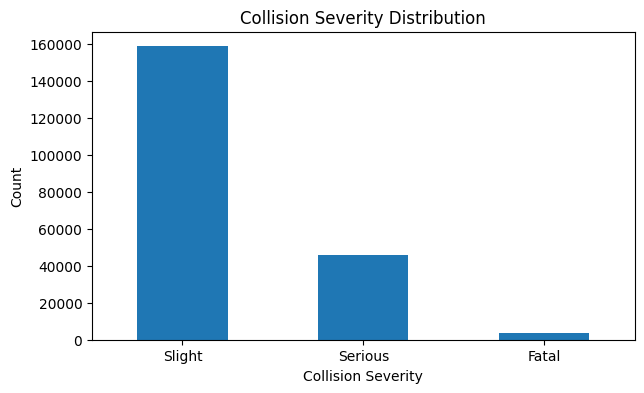

In [ ]:
import matplotlib.pyplot as plt

severity_labels = map_labels_for_display(df_final["collision_severity"], collision_severity_map)

severity_counts = severity_labels.value_counts(dropna=False)
severity_props = (severity_labels.value_counts(normalize=True, dropna=False) * 100).round(2)

print("Collision severity counts:")
display(severity_counts.to_frame("count"))

print("Collision severity percentages:")
display(severity_props.to_frame("percentage"))

plt.figure(figsize=(7, 4))
severity_counts.plot(kind="bar")
plt.title("Collision Severity Distribution")
plt.xlabel("Collision Severity")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 2.2 Missing Values Analysis
This subsection identifies the most incomplete variables in the merged dataset. Because the data comes from three linked tables, many missing values are expected after merging, especially for casualty-specific variables.

The goal here is to measure missingness clearly before deciding how to handle it later in Data Cleaning.

In [ ]:
import pandas as pd
import numpy as np

missing_code_map = {
    "collision_index": [],
    "collision_year_collision": [],
    "collision_ref_no_collision": [],
    "location_easting_osgr": [],
    "location_northing_osgr": [],
    "longitude": [],
    "latitude": [],
    "police_force": [],
    "collision_severity": [],
    "number_of_vehicles": [],
    "number_of_casualties": [],
    "date": [],
    "day_of_week": [],
    "time": [],
    "local_authority_district": [-1],
    "local_authority_ons_district": [-1],
    "local_authority_highway": [-1],
    "local_authority_highway_current": [],
    "first_road_class": [-1],
    "first_road_number": [-1],
    "road_type": [9, -1],
    "speed_limit": [99, -1],
    "junction_detail_historic": [99, -1],
    "junction_detail": [99, -1],
    "junction_control": [9, -1],
    "second_road_class": [9, -1],
    "second_road_number": [-1],
    "pedestrian_crossing_human_control_historic": [9, -1],
    "pedestrian_crossing_physical_facilities_historic": [9, -1],
    "pedestrian_crossing": [99, -1],
    "light_conditions": [7, -1],
    "weather_conditions": [9, -1],
    "road_surface_conditions": [9, -1],
    "special_conditions_at_site": [9, -1],
    "carriageway_hazards_historic": [9, -1],
    "carriageway_hazards": [99, -1],
    "urban_or_rural_area": [-1],
    "did_police_officer_attend_scene_of_accident": [-1],
    "trunk_road_flag": [-1],
    "lsoa_of_accident_location": [-1],
    "enhanced_severity_collision": [-1],
    "collision_injury_based": [],
    "collision_adjusted_severity_serious": [],
    "collision_adjusted_severity_slight": [],
    "collision_year_vehicle": [],
    "collision_ref_no_vehicle": [],
    "vehicle_reference": [],
    "vehicle_type": [99, -1],
    "towing_and_articulation": [9, -1],
    "vehicle_manoeuvre_historic": [99, -1],
    "vehicle_manoeuvre": [99, -1],
    "vehicle_direction_from": [9, -1],
    "vehicle_direction_to": [9, -1],
    "vehicle_location_restricted_lane_historic": [99, -1],
    "vehicle_location_restricted_lane": [99, -1],
    "junction_location": [9, -1],
    "skidding_and_overturning": [9, -1],
    "hit_object_in_carriageway": [99, -1],
    "vehicle_leaving_carriageway": [9, -1],
    "hit_object_off_carriageway": [99, -1],
    "first_point_of_impact": [9, -1],
    "vehicle_left_hand_drive": [9, -1],
    "journey_purpose_of_driver_historic": [6, 15, -1],
    "journey_purpose_of_driver": [6, -1],
    "sex_of_driver": [3, -1],
    "age_of_driver": [-1],
    "age_band_of_driver": [-1],
    "engine_capacity_cc": [-1],
    "propulsion_code": [-1],
    "age_of_vehicle": [-1],
    "lsoa_of_driver": [-1],
    "escooter_flag": [],
    "generic_make_model": [-1],
    "driver_imd_decile": [-1],
    "driver_distance_banding": [-1],
    "collision_year": [],
    "collision_ref_no": [],
    "casualty_reference": [],
    "casualty_class": [],
    "sex_of_casualty": [9, -1],
    "age_of_casualty": [-1],
    "age_band_of_casualty": [-1],
    "casualty_severity": [],
    "pedestrian_location": [10, -1],
    "pedestrian_movement": [9, -1],
    "car_passenger": [9, -1],
    "bus_or_coach_passenger": [9, -1],
    "pedestrian_road_maintenance_worker": [2, -1],
    "casualty_type": [99, -1],
    "casualty_imd_decile": [-1],


    "lsoa_of_casualty": [-1],
    "enhanced_casualty_severity": [-1],
    "casualty_injury_based": [],
    "casualty_adjusted_severity_serious": [],
    "casualty_adjusted_severity_slight": [],
    "casualty_distance_banding": [-1],
}

rows = []

for col in df_final.columns:
    codes = missing_code_map.get(col, [])
    s = df_final[col]

    if codes:
        mask_num = pd.to_numeric(s, errors="coerce").isin(codes)
        mask_str = s.astype(str).str.strip().isin([str(code) for code in codes])
        missing_mask = mask_num | mask_str
    else:
        missing_mask = pd.Series(False, index=s.index)

    rows.append({
        "feature": col,
        "missing_count": int(missing_mask.sum()),
        "missing_percent": round(missing_mask.mean() * 100, 2)
    })

real_missing_summary = (
    pd.DataFrame(rows)
    .sort_values(["missing_percent", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

real_missing_summary = real_missing_summary[real_missing_summary["missing_percent"] > 0]

display(real_missing_summary)

,feature,missing_count,missing_percent
0,local_authority_district,207816,100.00
1,driver_distance_banding,207816,100.00
2,journey_purpose_of_driver,156110,75.12
3,casualty_distance_banding,132977,63.99
4,journey_purpose_of_driver_historic,119235,57.38
5,enhanced_severity_collision,94244,45.35
6,junction_control,91420,43.99
7,second_road_number,85725,41.25
8,enhanced_casualty_severity,58820,28.30
9,lsoa_of_driver,49611,23.87


## 2.3 Numerical Feature Analysis
This subsection examines the distributions, spread, outliers, and skewness of key numerical variables. The objective is to identify which variables may later require transformation, robust scaling, binning, or careful treatment of special values such as `-1`.

In [ ]:
numerical_features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle",
    "age_of_casualty",
    "location_easting_osgr",
    "location_northing_osgr",
    "longitude",
    "latitude"
]

existing_numerical_features = [col for col in numerical_features if col in df_final.columns]

display(df_final[existing_numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
speed_limit,207816.0,36.818195,14.794211,20.000000,30.000000,30.000000,40.000000,7.000000e+01
number_of_vehicles,207816.0,2.074542,0.864705,1.000000,2.000000,2.000000,2.000000,1.700000e+01
number_of_casualties,207816.0,1.523333,1.658605,1.000000,1.000000,1.000000,2.000000,7.000000e+01
age_of_driver,207816.0,35.038313,21.608793,-1.000000,22.000000,35.000000,50.000000,1.000000e+02
engine_capacity_cc,207816.0,1396.767097,1562.798427,-1.000000,125.000000,1390.000000,1951.000000,2.998000e+04
age_of_vehicle,207816.0,6.778670,6.557492,-1.000000,1.000000,6.000000,11.000000,1.230000e+02
age_of_casualty,132977.0,37.168555,19.856626,-1.000000,22.000000,34.000000,51.000000,9.900000e+01
location_easting_osgr,207795.0,455325.928506,92134.382663,70537.000000,393846.000000,461388.000000,529391.500000,6.551600e+05
location_northing_osgr,207795.0,275759.299959,145920.043784,10528.000000,174924.000000,218465.000000,383620.000000,1.152174e+06
longitude,207795.0,-1.205622,1.347340,-7.429339,-2.092411,-1.091238,-0.135052,1.756018e+00


In [ ]:
skewness_table = df_final[existing_numerical_features].skew(numeric_only=True).sort_values(ascending=False)
skewness_table = skewness_table.to_frame("skewness")
display(skewness_table)

,skewness
number_of_casualties,25.170054
engine_capacity_cc,4.165586
number_of_vehicles,3.712930
location_northing_osgr,1.152014
latitude,1.142823
speed_limit,0.988887
age_of_vehicle,0.904858
age_of_casualty,0.422372
age_of_driver,0.026535
location_easting_osgr,-0.555443


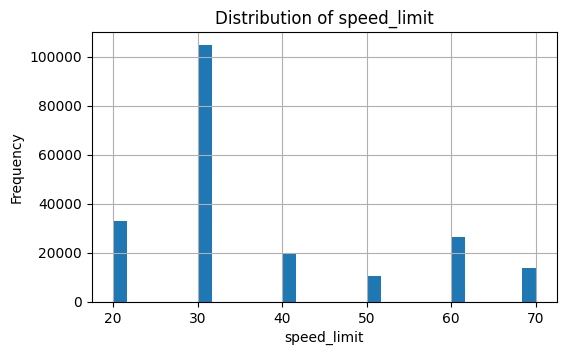

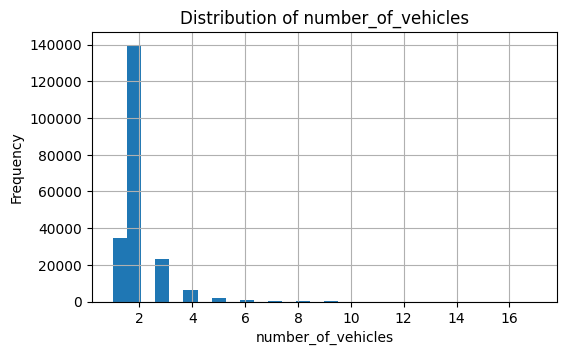

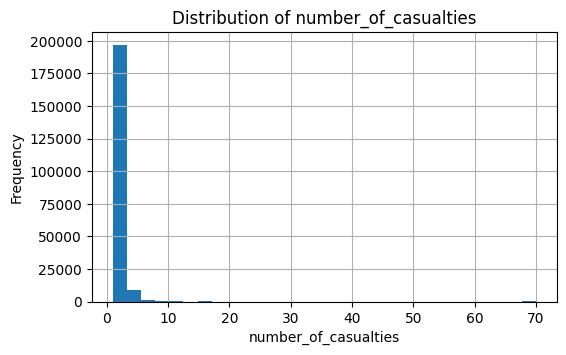

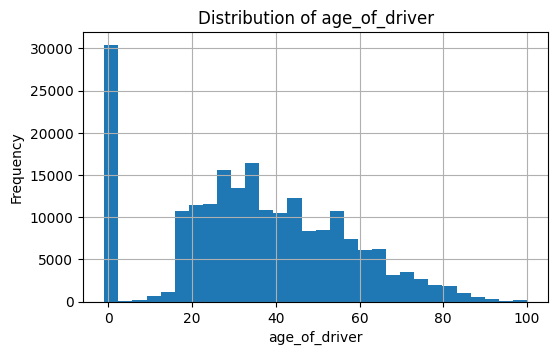

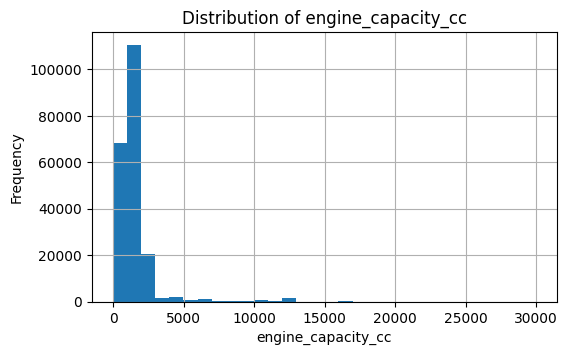

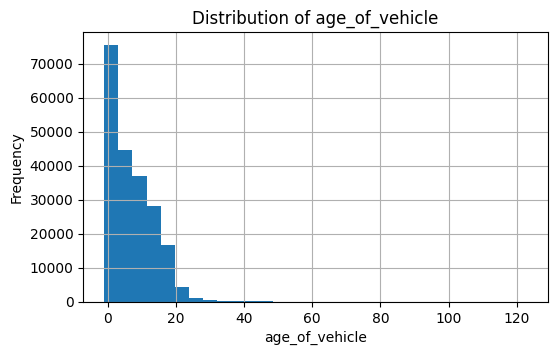

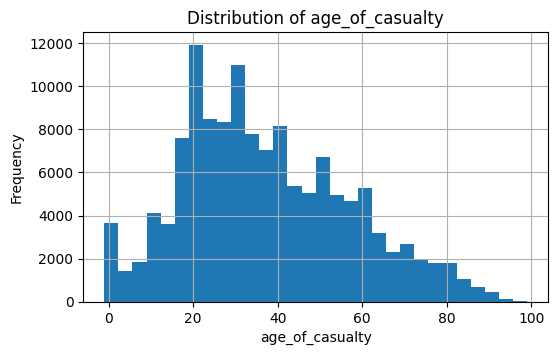

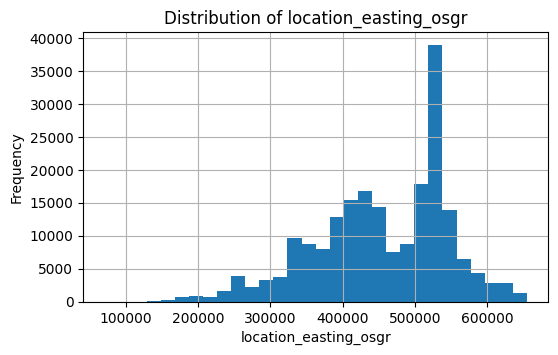

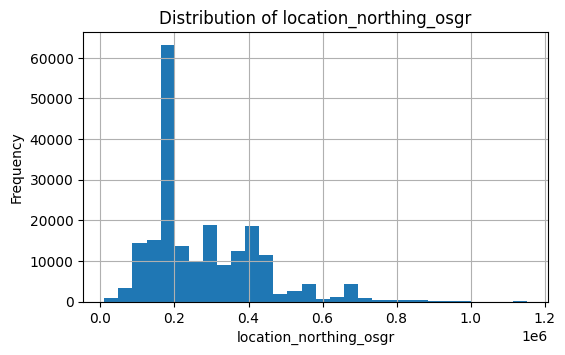

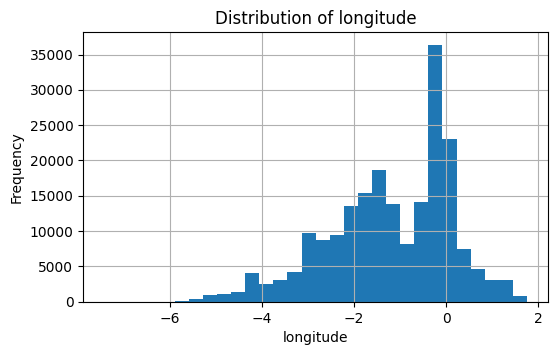

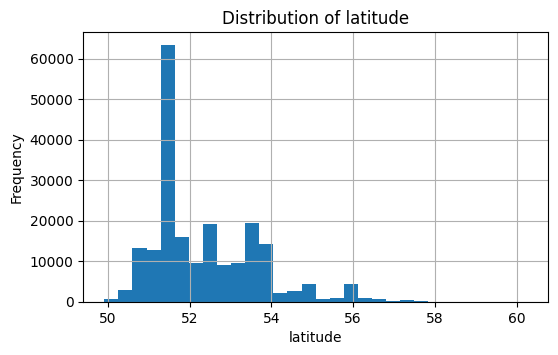

In [ ]:
for col in existing_numerical_features:
    plt.figure(figsize=(6, 3.5))
    df_final[col].dropna().hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 2.4 Categorical Feature Analysis
This subsection explores important categorical variables. To keep the dataset schema clean, readable labels should be used in plots only when needed, without permanently decoding the dataframe.

In [ ]:
categorical_features = [
    "road_type",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "vehicle_type",
    "casualty_class"
]

existing_categorical_features = [col for col in categorical_features if col in df_final.columns]
existing_categorical_features

['road_type',
 'weather_conditions',
 'light_conditions',
 'road_surface_conditions',
 'urban_or_rural_area',
 'vehicle_type',
 'casualty_class']


Top categories for road_type:


,count
road_type,
Single carriageway,148146
Dual carriageway,33992
Roundabout,12067
Unknown,5883
One way street,3908
Slip road,3820


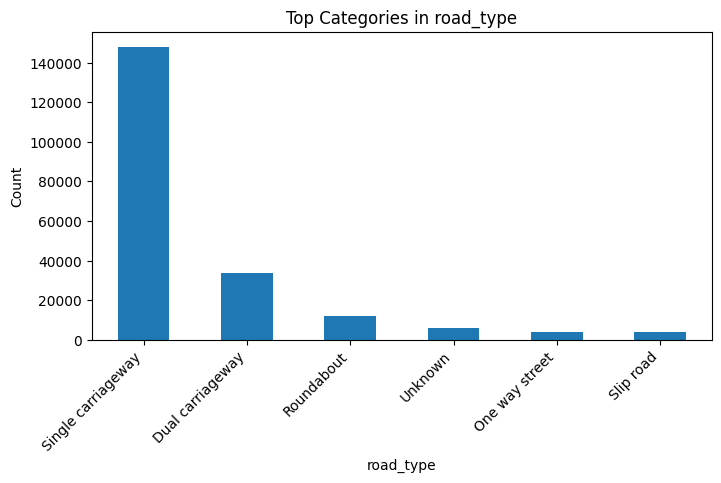


Top categories for weather_conditions:


,count
weather_conditions,
Fine no high winds,164633
Raining no high winds,25521
Unknown,6047
Other,5913
Raining + high winds,2278
Fine + high winds,1881
Snowing no high winds,815
Fog or mist,639
Snowing + high winds,89


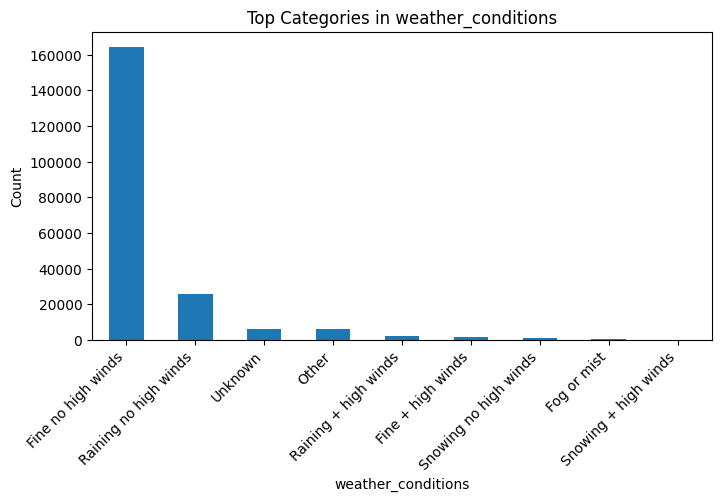


Top categories for light_conditions:


,count
light_conditions,
Daylight,148931
Darkness - lights lit,43388
Darkness - no lighting,11022
Darkness - lighting unknown,3006
Darkness - lights unlit,1469


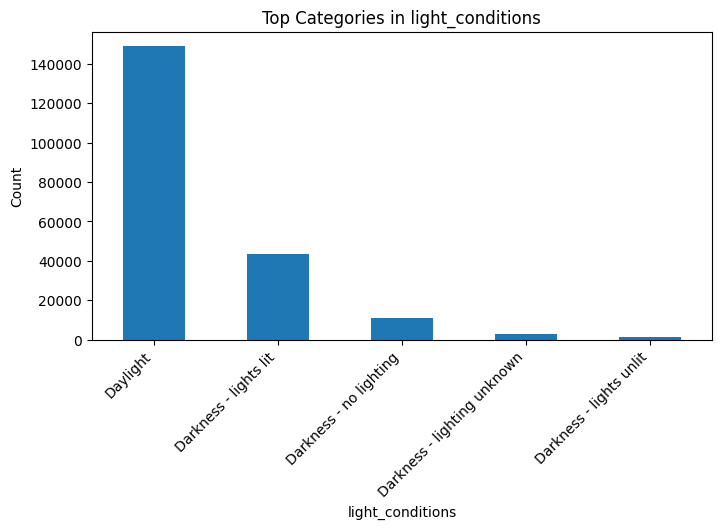


Top categories for road_surface_conditions:


,count
road_surface_conditions,
Dry,145668
Wet or damp,53490
9,3002
Frost or ice,2782
Missing / Out of range,2053
Snow,499
Flood over 3cm,322


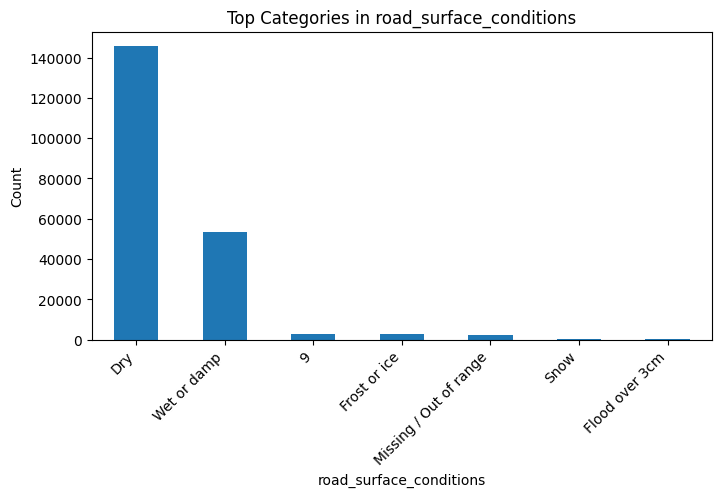


Top categories for urban_or_rural_area:


,count
urban_or_rural_area,
Urban,135824
Rural,71971
-1,13
Unallocated,8


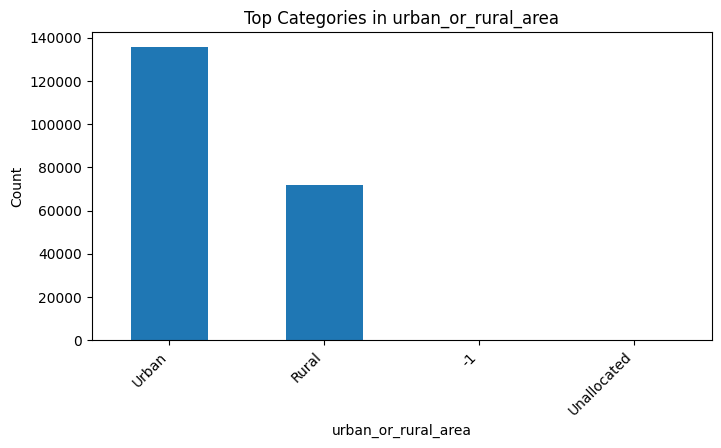


Top categories for vehicle_type:


,count
vehicle_type,
Car,145387
Pedal cycle,15812
Van / Goods vehicle <= 3.5t,12286
Motorcycle 125cc and under,9904
Motorcycle over 500cc,4681
Bus / Coach,4013
Taxi / Private hire car,3488
Goods vehicle >= 7.5t,2665
Motorcycle over 125cc and up to 500cc,2079


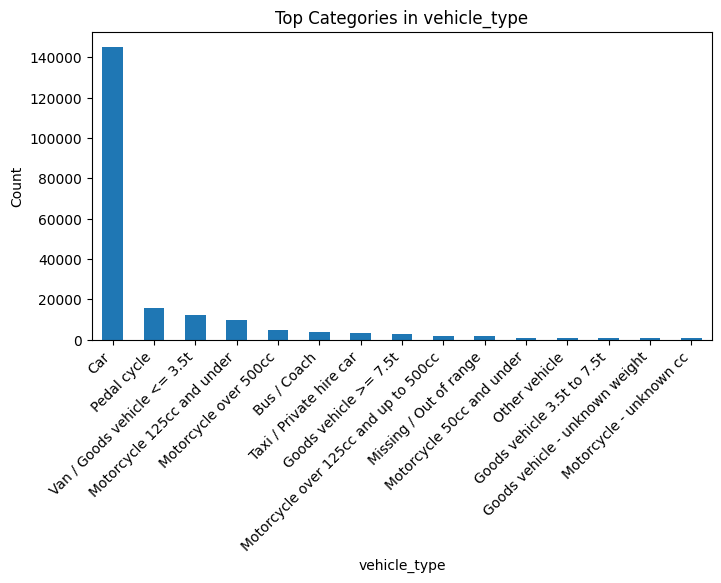


Top categories for casualty_class:


,count
casualty_class,
Driver or rider,87417
nan,74839
Passenger,26297
Pedestrian,19263


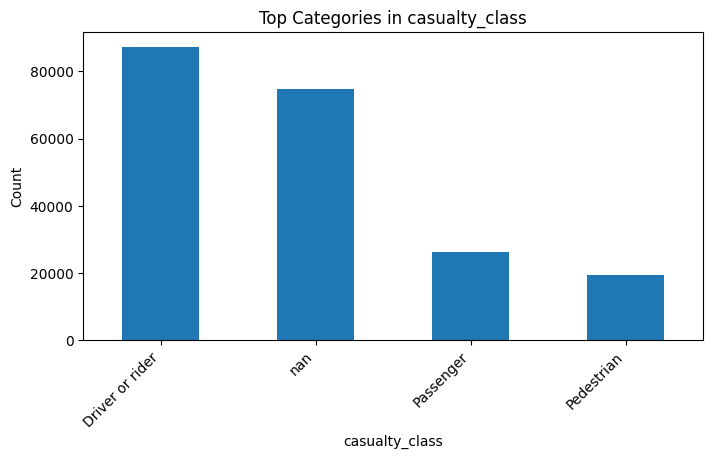

In [ ]:
for col in existing_categorical_features:
    display_series = map_labels_for_display(df_final[col], eda_label_maps.get(col, {}))
    value_counts = display_series.value_counts(dropna=False).head(15)

    print(f"\nTop categories for {col}:")
    display(value_counts.to_frame("count"))

    plt.figure(figsize=(8, 4))
    value_counts.plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()

## 2.5 Relationship Between Features and Target
This subsection explores how important predictors relate to `collision_severity`. The purpose is to identify patterns that may later guide cleaning, engineering, and feature selection.

collision_severity,Fatal,Serious,Slight
road_type,,,
Dual carriageway,2.07,20.66,77.27
One way street,0.41,16.43,83.16
Roundabout,0.55,15.65,83.81
Single carriageway,1.76,23.85,74.39
Slip road,1.26,16.65,82.09
Unknown,0.12,6.78,93.10


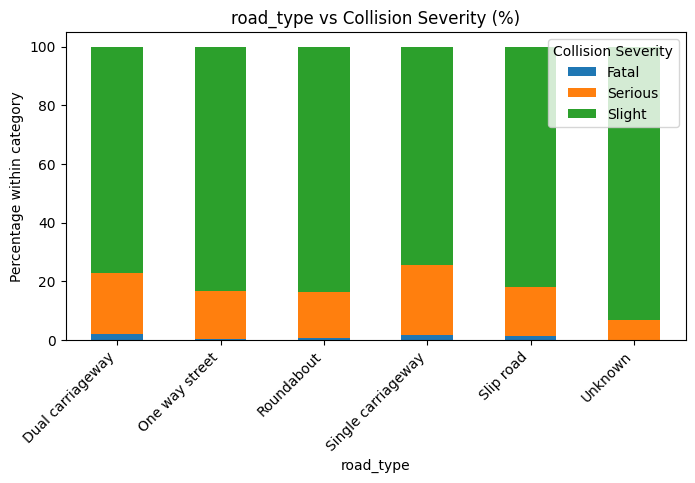

collision_severity,Fatal,Serious,Slight
weather_conditions,,,
Fine + high winds,2.87,27.33,69.80
Fine no high winds,1.70,22.60,75.70
Fog or mist,1.72,23.00,75.27
Other,0.83,18.30,80.87
Raining + high winds,3.42,22.74,73.84
Raining no high winds,1.65,22.23,76.12
Snowing + high winds,0.00,33.71,66.29
Snowing no high winds,2.45,21.72,75.83
Unknown,0.20,9.62,90.18


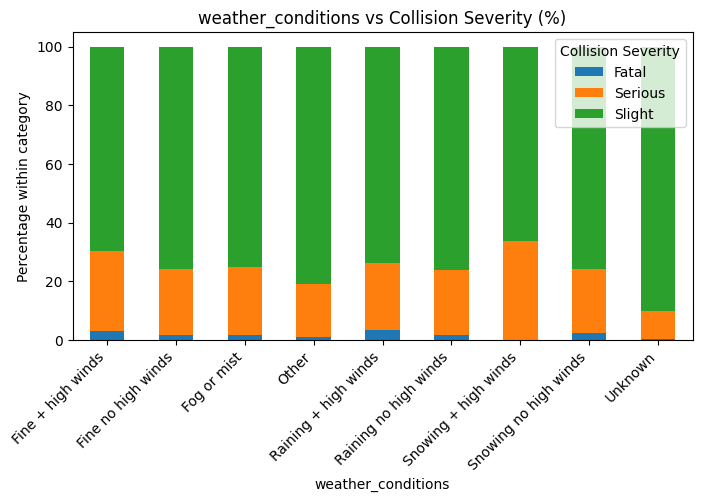

collision_severity,Fatal,Serious,Slight
light_conditions,,,
Darkness - lighting unknown,2.53,17.17,80.31
Darkness - lights lit,1.60,22.16,76.24
Darkness - lights unlit,3.47,22.94,73.59
Darkness - no lighting,5.15,32.16,62.68
Daylight,1.38,21.43,77.19


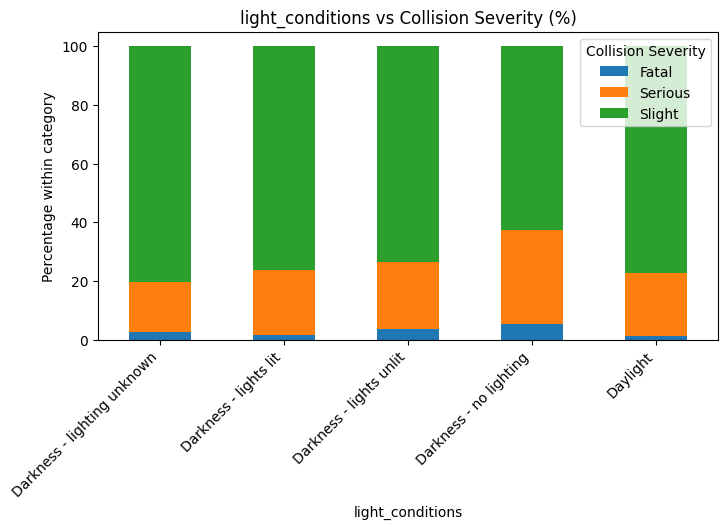

collision_severity,Fatal,Serious,Slight
urban_or_rural_area,,,
-1,0.00,23.08,76.92
Rural,3.22,26.68,70.10
Unallocated,0.00,37.50,62.50
Urban,0.84,19.67,79.50


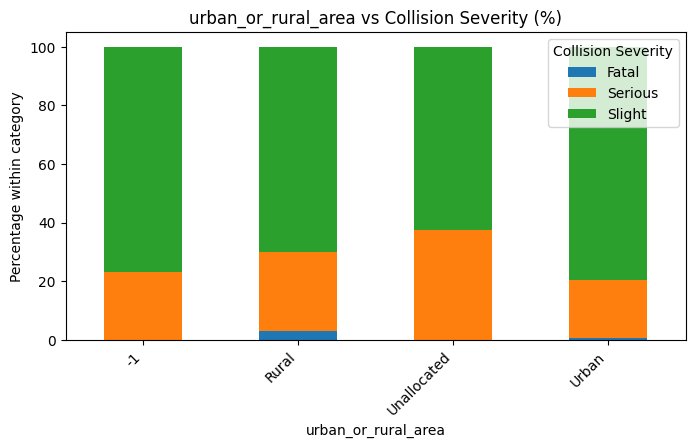

collision_severity,Fatal,Serious,Slight
vehicle_type,,,
99,3.85,11.54,84.62
Agricultural vehicle,4.52,36.44,59.04
Bus / Coach,2.22,25.94,71.84
Car,1.61,20.48,77.92
Electric motorcycle,1.72,39.83,58.45
Goods vehicle - unknown weight,1.24,15.30,83.46
Goods vehicle 3.5t to 7.5t,4.04,19.24,76.72
Goods vehicle >= 7.5t,6.53,24.54,68.93
Minibus,1.09,25.14,73.77


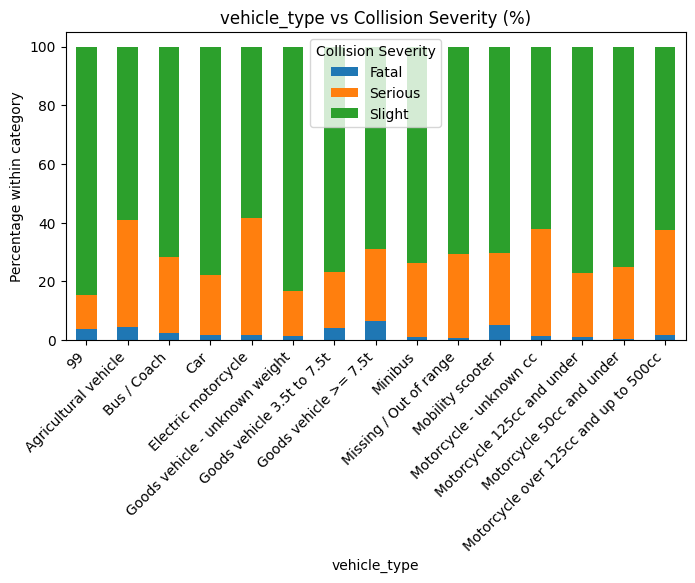

collision_severity,Fatal,Serious,Slight
casualty_class,,,
Driver or rider,1.64,22.22,76.14
Passenger,2.91,25.17,71.92
Pedestrian,2.38,30.83,66.80
nan,1.05,18.63,80.31


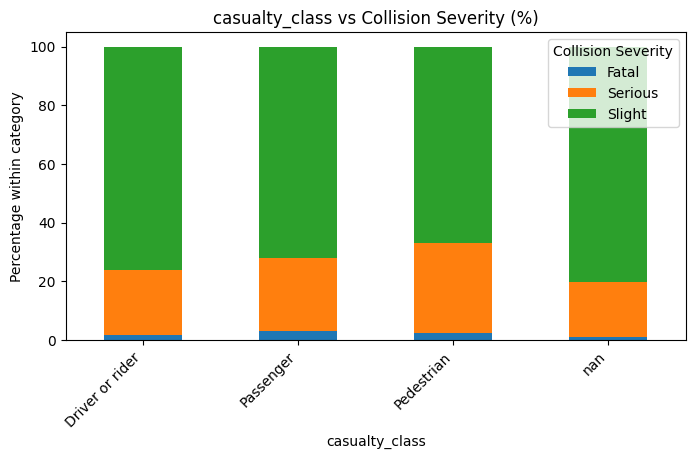

In [ ]:
relationship_features = [
    "road_type",
    "weather_conditions",
    "light_conditions",
    "urban_or_rural_area",
    "vehicle_type",
    "casualty_class"
]

relationship_features = [col for col in relationship_features if col in df_final.columns]

target_labels = map_labels_for_display(df_final["collision_severity"], collision_severity_map)

for col in relationship_features:
    feature_labels = map_labels_for_display(df_final[col], eda_label_maps.get(col, {}))

    ct = pd.crosstab(feature_labels, target_labels, normalize="index") * 100
    ct = ct.head(15)

    display(ct.round(2))

    ct.plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"{col} vs Collision Severity (%)")
    plt.xlabel(col)
    plt.ylabel("Percentage within category")
    plt.legend(title="Collision Severity")
    plt.xticks(rotation=45, ha="right")
    plt.show()

<Figure size 700x400 with 0 Axes>

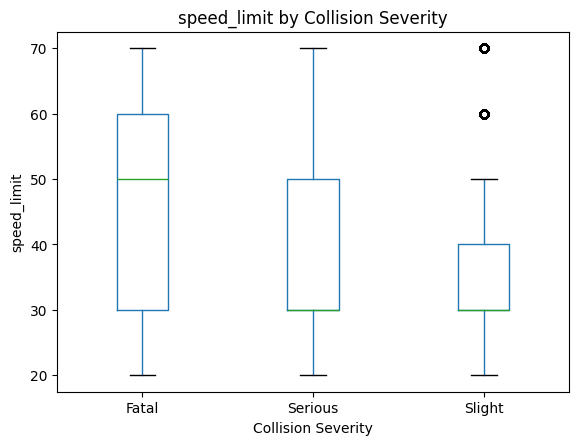

<Figure size 700x400 with 0 Axes>

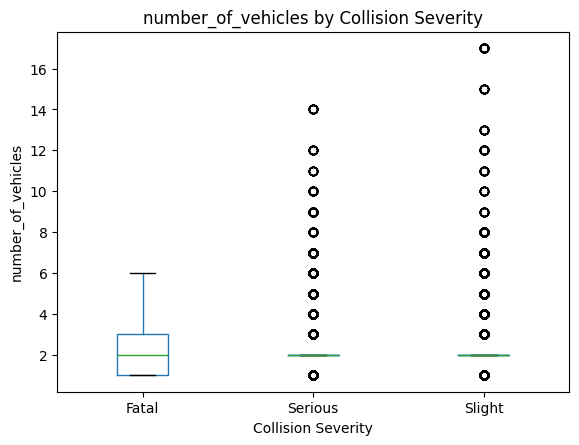

<Figure size 700x400 with 0 Axes>

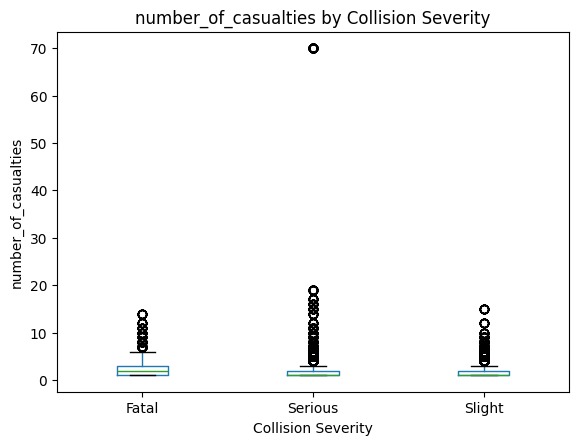

<Figure size 700x400 with 0 Axes>

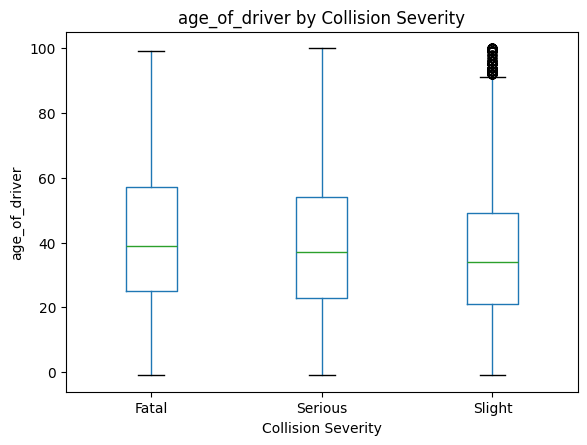

In [ ]:
severity_plot_labels = map_labels_for_display(df_final["collision_severity"], collision_severity_map)

for col in ["speed_limit", "number_of_vehicles", "number_of_casualties", "age_of_driver"]:
    if col in df_final.columns:
        plot_df = pd.DataFrame({
            col: df_final[col],
            "collision_severity_label": severity_plot_labels
        })

        plt.figure(figsize=(7, 4))
        plot_df.boxplot(column=col, by="collision_severity_label", grid=False)
        plt.title(f"{col} by Collision Severity")
        plt.suptitle("")
        plt.xlabel("Collision Severity")
        plt.ylabel(col)
        plt.show()

## 2.6 Correlation Analysis
This subsection studies numerical relationships between features. The goal is to identify early signs of redundancy and possible multicollinearity, which will later be addressed more formally in feature selection.

In [ ]:
correlation_features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle",
    "age_of_casualty",
    "collision_adjusted_severity_serious",
    "collision_adjusted_severity_slight",
    "casualty_adjusted_severity_serious",
    "casualty_adjusted_severity_slight"
]

correlation_features = [col for col in correlation_features if col in df_final.columns]

corr_matrix = df_final[correlation_features].corr(numeric_only=True)
display(corr_matrix.round(3))

,speed_limit,number_of_vehicles,number_of_casualties,age_of_driver,engine_capacity_cc,age_of_vehicle,age_of_casualty,collision_adjusted_severity_serious,collision_adjusted_severity_slight,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight
speed_limit,1.000,0.130,0.137,0.149,0.139,0.098,0.074,0.091,-0.120,0.045,-0.064
number_of_vehicles,0.130,1.000,0.137,-0.011,0.046,0.010,0.046,-0.014,0.011,-0.090,0.094
number_of_casualties,0.137,0.137,1.000,0.068,0.114,0.057,-0.034,0.107,-0.128,-0.020,0.016
age_of_driver,0.149,-0.011,0.068,1.000,0.139,0.105,0.653,0.084,-0.094,0.043,-0.051
engine_capacity_cc,0.139,0.046,0.114,0.139,1.000,0.283,0.079,0.004,-0.021,-0.044,0.034
age_of_vehicle,0.098,0.010,0.057,0.105,0.283,1.000,0.022,0.015,-0.024,-0.001,-0.009
age_of_casualty,0.074,0.046,-0.034,0.653,0.079,0.022,1.000,0.069,-0.083,0.081,-0.095
collision_adjusted_severity_serious,0.091,-0.014,0.107,0.084,0.004,0.015,0.069,1.000,-0.953,0.852,-0.814
collision_adjusted_severity_slight,-0.120,0.011,-0.128,-0.094,-0.021,-0.024,-0.083,-0.953,1.000,-0.830,0.863
casualty_adjusted_severity_serious,0.045,-0.090,-0.020,0.043,-0.044,-0.001,0.081,0.852,-0.830,1.000,-0.962


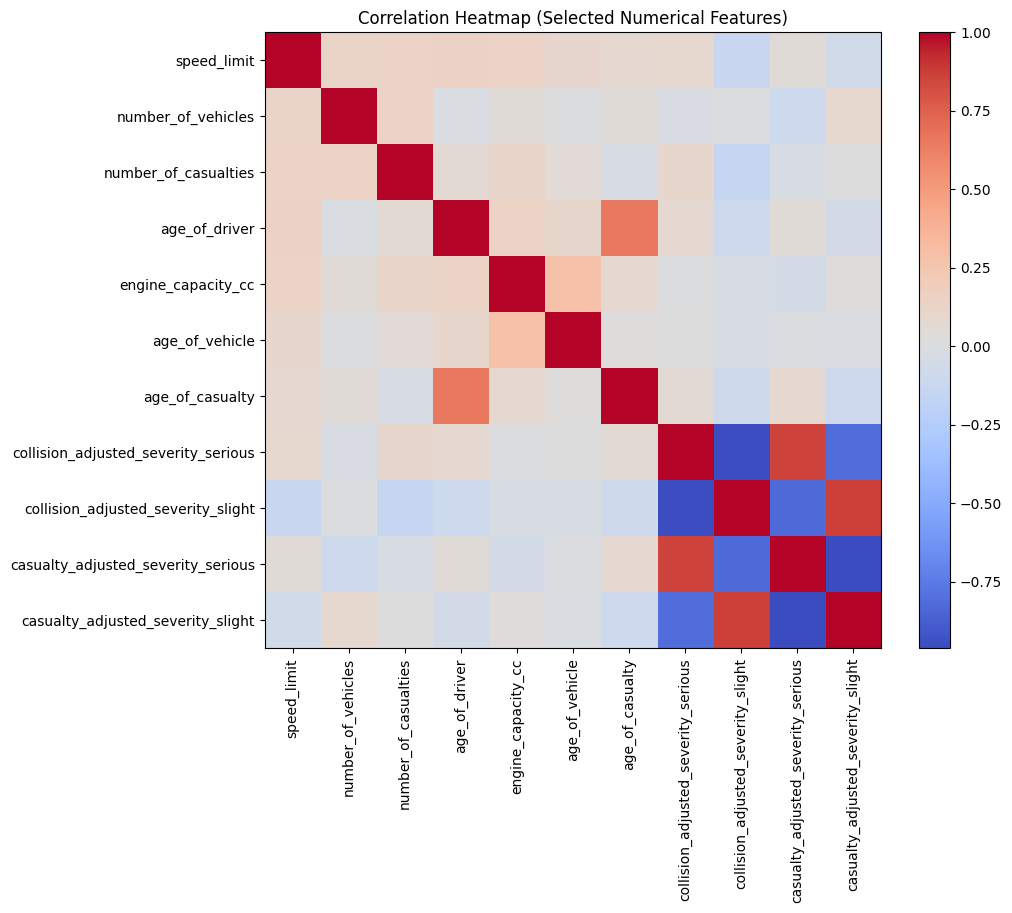

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap (Selected Numerical Features)")
plt.show()

.

.

## 2.7 EDA Analysis & Required Actions

The exploratory analysis shows that the merged UK road safety dataset is large and information-rich, with 207,816 records, 96 features, and no exact duplicate rows. The target variable, collision_severity, is strongly imbalanced:

2.1 Target Analysis: The collision_severity distribution (severity_counts shows Slight: 158,444 (76.24%), Serious: 45,922 (22.10%), Fatal: 3,450 (1.66%)). This strong class imbalance, particularly the rarity of Fatal collisions, means the dataset is dominated by low-severity outcomes. This requires careful handling during modeling, possibly through oversampling, undersampling, or class weighting.

2.2 Missing Values Analysis: The real_missing_summary table indicates substantial missingness in many features, some with 100% missing data (e.g., local_authority_district, driver_distance_banding, casualty_distance_banding). This missingness isn't always standard NaN but includes various placeholder codes (e.g., -1, 9, 99) and structural missingness due to the merging of three tables. Required Action: A strategic approach to missing value imputation or removal is necessary. Features with a very high percentage of missingness should be considered for removal, while others might be imputed using domain-appropriate methods (e.g., median for numerical, mode for categorical), ensuring placeholder codes are treated as missing.

2.3 Numerical Feature Analysis: The skewness_table reveals several highly skewed numerical variables. number_of_casualties (skewness 25.17) is the most extreme, followed by engine_capacity_cc (4.17) and number_of_vehicles (3.71). Histograms confirm most collisions involve few vehicles/casualties, with a long upper tail. speed_limit (skewness 0.989) is concentrated around specific values (30, 40, 60, 70), indicating it behaves more like a discrete policy variable than a continuous one. Required Action: Highly skewed numerical variables should be transformed (e.g., log-transformed or binned) to normalize their distributions. speed_limit should be treated as an ordinal or discrete categorical variable.

2.4 Categorical Feature Analysis: The top categories for features like road_type, weather_conditions, light_conditions, urban_or_rural_area, vehicle_type, and casualty_class show a dominance of certain conditions (e.g., 'Single carriageway', 'Fine no high winds', 'Daylight', 'Urban', 'Car', 'Driver or rider'). The presence of nan and coded values like -1, 9, 99 (seen in value_counts for casualty_class) suggests these need proper handling. Required Action: Clean categorical features by properly handling these invalid/placeholder codes, either by remapping or treating them as distinct 'unknown' categories.

2.5 Relationship Between Features and Target: Cross-tabulations (e.g., ct for casualty_class vs. collision_severity) and box plots (e.g., age_of_driver by severity) indicate that collision_severity is not uniformly distributed across different contexts. For instance, nan values in casualty_class are heavily skewed towards 'Slight' collisions (80.31%). Rural collisions often show higher fatal proportions than urban ones, and 'Darkness - no lighting' has a more severe distribution than 'Daylight'. This suggests that road environment, lighting, location type, vehicle type, and casualty role all contain useful signals for modeling. Required Action: Pay close attention to features that show a clear differential distribution across target classes, as these will be strong predictors.

2.6 Correlation Analysis: The corr_matrix shows that most standard numerical variables are weakly to moderately correlated. However, collision_adjusted_severity_serious and collision_adjusted_severity_slight have a very high negative correlation (-0.953), and casualty_adjusted_severity_serious and casualty_adjusted_severity_slight similarly (-0.962). These are problematic as they are likely derived from or directly related to the target. Required Action: All severity-adjusted and derived severity variables (e.g., collision_adjusted_*, casualty_adjusted_*, enhanced_*, *_injury_based) must be removed to prevent target leakage, as they would inflate model performance unrealistically.

Overall Required Actions Summary:

Target Leakage Prevention: Remove all severity-adjusted, enhanced, or injury-based features from the dataset (e.g., collision_adjusted_severity_serious, casualty_adjusted_severity_slight, enhanced_severity_collision) due to their high correlation with the target and potential to leak information. (Identified in 2.6)
Target Imbalance Handling: Prepare the collision_severity target for modeling by applying techniques such as oversampling, undersampling, or class weighting to address the severe imbalance. (Identified in 2.1)
Numerical Feature Transformation: Apply transformations (e.g., log transformation) to highly skewed numerical features (number_of_casualties, number_of_vehicles, engine_capacity_cc) to improve their distribution for modeling. (Identified in 2.3)
Categorical Feature Treatment: Convert speed_limit to an ordinal or categorical type. Address placeholder values (e.g., -1, 9, 99) in all categorical features by either treating them as a specific 'unknown' category or imputing them with an appropriate strategy. (Identified in 2.3, 2.4)
Missing Value Strategy: Develop a clear strategy for handling features with high percentages of missing data (including placeholder codes). This may involve dropping features that are too sparse or imputing others based on their type and missingness level. (Identified in 2.2)
Spatial Feature Selection: Decide on which spatial coordinates (longitude, latitude, location_easting_osgr, location_northing_osgr) to retain, potentially dropping redundant ones (e.g., OSGR coordinates if latitude and longitude are kept). (Implied from 2.2 for potential redundancy, and noted for being proxies for conditions).

# 3. Data Cleaning
This section addresses the main issues identified in the exploratory analysis. The objective is to improve data quality and prepare a more reliable modeling dataset without yet performing advanced feature engineering or formal feature selection.

The cleaning process focuses on:
- removing variables that are identifiers, administrative labels, historic duplicates, or clear leakage sources
- handling invalid placeholder values such as `-1`
- dealing with missing values in a controlled and interpretable way
- simplifying the merged dataset while preserving useful predictive information

It is important to note that this section removes only variables that are clearly unnecessary or unsafe to keep. Additional variables may still be removed later in **Feature Selection** based on redundancy, multicollinearity, statistical relevance, and model-based evidence.

## 3.1 Removing Clearly Unnecessary Features
Some variables are removed at this stage because they are not appropriate predictors for collision severity. These variables fall into several groups:

- identifiers and reference fields, which uniquely identify records but do not carry predictive meaning
- administrative and geographic codes that are too specific, too high-cardinality, or mainly useful for matching rather than modeling
- historic duplicate fields, where a newer version of the same concept already exists
- outcome-related or severity-adjusted fields that are too close to the target and may cause target leakage
- post-collision response variables that reflect what happened after the event rather than the conditions that help predict it
- redundant raw location coordinate systems where a more interpretable alternative already exists

This is an intentional early filtering step. More refined removal based on technical criteria such as VIF, correlation, chi-square, ANOVA, RFE, and model importance will be done later in Feature Selection.

In [ ]:
# Work on a copy for cleaning
df_clean = df_final.copy()

print("Initial shape before cleaning:", df_clean.shape)

Initial shape before cleaning: (207816, 96)


In [ ]:
# Columns that are clearly unnecessary or unsafe to keep at this stage
drop_reasons = {
    # IDs / references
    "collision_index": "Unique record ID, so it does not help prediction.",
    "collision_ref_no": "Reference number, so it acts like an identifier rather than a meaningful feature.",
    "collision_ref_no_collision": "Reference number, so it acts like an identifier rather than a meaningful feature.",
    "collision_ref_no_vehicle": "Reference number, so it acts like an identifier rather than a meaningful feature.",
    "vehicle_reference": "Vehicle reference is mainly an identifier inside each collision, not a meaningful predictor.",
    "casualty_reference": "Casualty reference is mainly an identifier, not a meaningful predictive feature.",

    # Year / duplicated merge columns
    "collision_year": "The dataset is already from one year, so this variable adds no useful information.",
    "collision_year_collision": "The dataset is already from one year, so this variable adds no useful information.",
    "collision_year_vehicle": "The dataset is already from one year, so this variable adds no useful information.",

    # Administrative / matching / high-cardinality area fields
    "local_authority_district": "Administrative area code that is too specific and may not generalize well.",
    "local_authority_ons_district": "Administrative matching code, not a meaningful road-condition feature.",
    "local_authority_highway": "Administrative highway label, mainly useful for matching rather than prediction.",
    "local_authority_highway_current": "Updated administrative highway label, not a core predictive feature.",
    "lsoa_of_accident_location": "Very detailed area code that is too location-specific and high-cardinality.",
    "lsoa_of_driver": "Very detailed residential area code that is too specific and high-cardinality.",
    "lsoa_of_casualty": "Very detailed residential area code that is too specific and high-cardinality.",

    # Leakage / outcome-derived
    "enhanced_severity_collision": "Severity-related variable derived from the outcome, so it may cause leakage.",
    "collision_injury_based": "Outcome-related variable that may leak target information into the model.",
    "collision_adjusted_severity_serious": "Derived severity field that may leak the target.",
    "collision_adjusted_severity_slight": "Derived severity field that may leak the target.",
    "enhanced_casualty_severity": "Casualty severity-related variable that is too close to the outcome structure and may leak information.",
    "casualty_injury_based": "Outcome-related casualty variable that may leak target information.",
    "casualty_adjusted_severity_serious": "Derived casualty severity field that may leak target information.",
    "casualty_adjusted_severity_slight": "Derived casualty severity field that may leak target information.",

    # Location duplication
    "location_easting_osgr": "Coordinate field removed because latitude and longitude already represent location.",
    "location_northing_osgr": "Coordinate field removed because latitude and longitude already represent location.",

    # Road reference numbers / pseudo-identifiers
    "first_road_number": "Road reference number with too many unique values, so it behaves like an identifier.",
    "second_road_number": "Road reference number with too many unique values, so it behaves like an identifier.",

    # Historic duplicates
    "junction_detail_historic": "Older version of junction detail, so keeping the newer field is cleaner.",
    "pedestrian_crossing_human_control_historic": "Historic duplicate field, so it was removed to avoid redundancy.",
    "pedestrian_crossing_physical_facilities_historic": "Historic duplicate field, so it was removed to avoid redundancy.",
    "carriageway_hazards_historic": "Historic duplicate field, so it was removed to avoid redundancy.",
    "vehicle_manoeuvre_historic": "Historic duplicate field, so keeping the newer field is cleaner.",
    "vehicle_location_restricted_lane_historic": "Historic duplicate field, so keeping the newer field is cleaner.",
    "journey_purpose_of_driver_historic": "Historic duplicate field, so keeping the newer field is cleaner.",

    # Post-event / reporting-related
    "did_police_officer_attend_scene_of_accident": "Post-collision response variable, not a clean road-condition predictor.",
    "police_force": "Administrative police region label that may capture reporting differences more than collision conditions.",

    # Very high-cardinality weak text-like field
    "generic_make_model": "Very high-cardinality make/model field that is too sparse and unstable in raw form for this stage."
}

# Keep only the columns that actually exist
columns_to_drop = [col for col in drop_reasons if col in df_clean.columns]

dropped_features_df = pd.DataFrame({
    "feature": columns_to_drop,
    "reason_for_removal": [drop_reasons[col] for col in columns_to_drop]
})

print("Number of features selected for removal in this cleaning step:", len(columns_to_drop))
display(dropped_features_df)

Number of features selected for removal in this cleaning step: 38


,feature,reason_for_removal
0,collision_index,"Unique record ID, so it does not help prediction."
1,collision_ref_no,"Reference number, so it acts like an identifier rather than a meaningful feature."
2,collision_ref_no_collision,"Reference number, so it acts like an identifier rather than a meaningful feature."
3,collision_ref_no_vehicle,"Reference number, so it acts like an identifier rather than a meaningful feature."
4,vehicle_reference,"Vehicle reference is mainly an identifier inside each collision, not a meaningful predictor."
5,casualty_reference,"Casualty reference is mainly an identifier, not a meaningful predictive feature."
6,collision_year,"The dataset is already from one year, so this variable adds no useful information."
7,collision_year_collision,"The dataset is already from one year, so this variable adds no useful information."
8,collision_year_vehicle,"The dataset is already from one year, so this variable adds no useful information."
9,local_authority_district,Administrative area code that is too specific and may not generalize well.


In [ ]:
# Drop the selected columns
df_clean = df_clean.drop(columns=columns_to_drop)

print("Shape after dropping clearly unnecessary features:", df_clean.shape)

Shape after dropping clearly unnecessary features: (207816, 58)


## 3.2 Parsing Date and Time Variables
The raw `date` and `time` columns are currently stored as text. They should be converted into structured datetime-compatible formats so they can later support time-based feature engineering such as hour, month, season, and weekend indicators.

At this stage, the goal is only to standardize their format, not yet to engineer new features.

In [ ]:
# Parse date correctly using UK format
df_clean["date"] = pd.to_datetime(df_clean["date"], dayfirst=True, errors="coerce")

## 3.3 Missing Value Handling
After removing clearly unnecessary features and converting invalid placeholder values to missing values, the next step is to handle missing data carefully.

The missingness in this project is not fully random. A large portion of missing values comes from the merging process, especially for casualty-related variables. Therefore, the handling strategy must balance two goals:
- preserve as much information as possible
- avoid introducing inconsistent or misleading values

The following approach is used:
- numerical variables are imputed using the median, which is robust to skewness and outliers
- categorical variables are imputed using the mode, which preserves the most common observed category

This is a practical and interpretable baseline cleaning choice. More advanced treatment of missingness can still be considered later if needed.

In [ ]:
import pandas as pd
import numpy as np

missing_code_map = {
    "collision_index": [],
    "collision_year_collision": [],
    "collision_ref_no_collision": [],
    "location_easting_osgr": [],
    "location_northing_osgr": [],
    "longitude": [],
    "latitude": [],
    "police_force": [],
    "collision_severity": [],
    "number_of_vehicles": [],
    "number_of_casualties": [],
    "date": [],
    "day_of_week": [],
    "time": [],
    "local_authority_district": [-1],
    "local_authority_ons_district": [-1],
    "local_authority_highway": [-1],
    "local_authority_highway_current": [],
    "first_road_class": [-1],
    "first_road_number": [-1],
    "road_type": [9, -1],
    "speed_limit": [99, -1],
    "junction_detail_historic": [99, -1],
    "junction_detail": [99, -1],
    "junction_control": [9, -1],
    "second_road_class": [9, -1],
    "second_road_number": [-1],
    "pedestrian_crossing_human_control_historic": [9, -1],
    "pedestrian_crossing_physical_facilities_historic": [9, -1],
    "pedestrian_crossing": [99, -1],
    "light_conditions": [7, -1],
    "weather_conditions": [9, -1],
    "road_surface_conditions": [9, -1],
    "special_conditions_at_site": [9, -1],
    "carriageway_hazards_historic": [9, -1],
    "carriageway_hazards": [99, -1],
    "urban_or_rural_area": [-1],
    "did_police_officer_attend_scene_of_accident": [-1],
    "trunk_road_flag": [-1],
    "lsoa_of_accident_location": [-1],
    "enhanced_severity_collision": [-1],
    "collision_injury_based": [],
    "collision_adjusted_severity_serious": [],
    "collision_adjusted_severity_slight": [],
    "collision_year_vehicle": [],
    "collision_ref_no_vehicle": [],
    "vehicle_reference": [],
    "vehicle_type": [99, -1],
    "towing_and_articulation": [9, -1],
    "vehicle_manoeuvre_historic": [99, -1],
    "vehicle_manoeuvre": [99, -1],
    "vehicle_direction_from": [9, -1],
    "vehicle_direction_to": [9, -1],
    "vehicle_location_restricted_lane_historic": [99, -1],
    "vehicle_location_restricted_lane": [99, -1],
    "junction_location": [9, -1],
    "skidding_and_overturning": [9, -1],
    "hit_object_in_carriageway": [99, -1],
    "vehicle_leaving_carriageway": [9, -1],
    "hit_object_off_carriageway": [99, -1],
    "first_point_of_impact": [9, -1],
    "vehicle_left_hand_drive": [9, -1],
    "journey_purpose_of_driver_historic": [6, 15, -1],
    "journey_purpose_of_driver": [6, -1],
    "sex_of_driver": [3, -1],
    "age_of_driver": [-1],
    "age_band_of_driver": [-1],
    "engine_capacity_cc": [-1],
    "propulsion_code": [-1],
    "age_of_vehicle": [-1],
    "lsoa_of_driver": [-1],
    "escooter_flag": [],
    "generic_make_model": [-1],
    "driver_imd_decile": [-1],
    "driver_distance_banding": [-1],
    "collision_year": [],
    "collision_ref_no": [],
    "casualty_reference": [],
    "casualty_class": [],
    "sex_of_casualty": [9, -1],
    "age_of_casualty": [-1],
    "age_band_of_casualty": [-1],
    "casualty_severity": [],
    "pedestrian_location": [10, -1],
    "pedestrian_movement": [9, -1],
    "car_passenger": [9, -1],
    "bus_or_coach_passenger": [9, -1],
    "pedestrian_road_maintenance_worker": [2, -1],
    "casualty_type": [99, -1],
    "casualty_imd_decile": [-1],


    "lsoa_of_casualty": [-1],
    "enhanced_casualty_severity": [-1],
    "casualty_injury_based": [],
    "casualty_adjusted_severity_serious": [],
    "casualty_adjusted_severity_slight": [],
    "casualty_distance_banding": [-1],
}


rows = []

for col in df_clean.columns:
    codes = missing_code_map.get(col, [])
    s = df_clean[col]

    if codes:
        mask_num = pd.to_numeric(s, errors="coerce").isin(codes)
        mask_str = s.astype(str).str.strip().isin([str(code) for code in codes])
        missing_mask = mask_num | mask_str
    else:
        missing_mask = pd.Series(False, index=s.index)

    rows.append({
        "feature": col,
        "missing_count": int(missing_mask.sum()),
        "missing_percent": round(missing_mask.mean() * 100, 2)
    })

real_missing_summary = (
    pd.DataFrame(rows)
    .sort_values(["missing_percent", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

real_missing_summary = real_missing_summary[real_missing_summary["missing_percent"] > 0]

display(real_missing_summary)

,feature,missing_count,missing_percent
0,driver_distance_banding,207816,100.00
1,journey_purpose_of_driver,156110,75.12
2,casualty_distance_banding,132977,63.99
3,junction_control,91420,43.99
4,engine_capacity_cc,45748,22.01
5,driver_imd_decile,43185,20.78
6,age_of_vehicle,42190,20.30
7,propulsion_code,42123,20.27
8,age_of_driver,30408,14.63
9,age_band_of_driver,30408,14.63


Impute:

In [ ]:
# Assuming real_missing_summary is already computed from the previous cell
# and df_clean still contains sentinel values as numbers/strings (no NaNs introduced)

imputation_log = []

# Create a copy of df_clean to ensure that the imputation is performed correctly
# and to avoid unintended modifications during the loop.
df_clean_imputed = df_clean.copy()

# Identify numerical and categorical columns based on their dtypes
numeric_cols = df_clean_imputed.select_dtypes(include=np.number).columns
categorical_cols = df_clean_imputed.select_dtypes(exclude=np.number).columns


for col in df_clean_imputed.columns:
    col_missing_info = real_missing_summary[real_missing_summary["feature"] == col]

    if not col_missing_info.empty:
        missing_percent = col_missing_info["missing_percent"].iloc[0]
        missing_codes = missing_code_map.get(col, [])

        # Only impute if missing_percent is below 25% and there are defined missing codes for the column
        if missing_percent < 25 and len(missing_codes) > 0:
            # Determine mask for all sentinel values in the column
            mask_has_codes = pd.Series(False, index=df_clean_imputed.index)
            if col in numeric_cols:
                mask_has_codes = df_clean_imputed[col].isin(missing_codes)
            elif col in categorical_cols: # Treat as categorical
                # Convert missing codes to string for comparison with object/categorical columns
                mask_has_codes = df_clean_imputed[col].astype(str).isin([str(c) for c in missing_codes])
            else:
                continue # Skip columns not clearly numeric or categorical for this imputation logic

            if mask_has_codes.any(): # Only proceed if there are sentinel values to replace
                fill_value = None
                if col in numeric_cols:
                    # Calculate median *excluding* the sentinel values
                    valid_data = df_clean_imputed[col][~mask_has_codes]
                    if not valid_data.empty:
                        fill_value = valid_data.median()
                        df_clean_imputed.loc[mask_has_codes, col] = fill_value
                        imputation_log.append({
                            "feature": col,
                            "type": "Numerical",
                            "method": "Median (excluding sentinels)",
                            "fill_value": fill_value,
                            "missing_filled": mask_has_codes.sum()
                        })
                elif col in categorical_cols:
                    # Calculate mode *excluding* the sentinel values
                    valid_data = df_clean_imputed[col][~mask_has_codes]
                    if not valid_data.empty:
                        fill_value = valid_data.mode()[0]
                        # Attempt to cast fill_value back to original dtype if it's not a native Python type
                        if isinstance(df_clean_imputed[col].dtype, pd.CategoricalDtype):
                            if fill_value not in df_clean_imputed[col].cat.categories:
                                df_clean_imputed[col] = df_clean_imputed[col].cat.add_categories([fill_value])
                        elif pd.api.types.is_integer_dtype(df_clean_imputed[col]) and isinstance(fill_value, float):
                             # Convert float median/mode to int if original was int and appropriate
                            fill_value = int(fill_value)

                        df_clean_imputed.loc[mask_has_codes, col] = fill_value
                        imputation_log.append({
                            "feature": col,
                            "type": "Categorical",
                            "method": "Mode (excluding sentinels)",
                            "fill_value": fill_value,
                            "missing_filled": mask_has_codes.sum()
                        })

# Update df_clean with the imputed version
df_clean = df_clean_imputed

# Final check: Recalculate remaining 'missing' values based on sentinel codes
# after imputation. This should show that some columns have had their sentinels replaced.
total_sentinels_after = 0
rows_after_imputation_check = []

for col in df_clean.columns:
    codes = missing_code_map.get(col, [])
    s = df_clean[col]

    # Re-evaluate missing_mask based on the current state of df_clean
    if codes:
        mask_num = pd.to_numeric(s, errors="coerce").isin(codes)
        mask_str = s.astype(str).str.strip().isin([str(code) for code in codes])
        remaining_sentinel_mask = mask_num | mask_str
    else:
        remaining_sentinel_mask = pd.Series(False, index=s.index)

    current_missing_count = int(remaining_sentinel_mask.sum())
    total_sentinels_after += current_missing_count
    rows_after_imputation_check.append({
        "feature": col,
        "remaining_sentinel_count": current_missing_count,
        "remaining_sentinel_percent": round(remaining_sentinel_mask.mean() * 100, 2)
    })

remaining_sentinel_summary = (
    pd.DataFrame(rows_after_imputation_check)
    .sort_values(["remaining_sentinel_percent", "remaining_sentinel_count"], ascending=False)
    .reset_index(drop=True)
)

print("\nRemaining 'missing' values (sentinel codes) after selective imputation (with < 25% threshold):")
display(remaining_sentinel_summary[remaining_sentinel_summary["remaining_sentinel_percent"] > 0])
print(f"Total number of sentinel values remaining in df_clean: {total_sentinels_after}")

print("\nImputation Log (for features with < 25% missing rate):")
display(pd.DataFrame(imputation_log))


Remaining 'missing' values (sentinel codes) after selective imputation (with < 25% threshold):


,feature,remaining_sentinel_count,remaining_sentinel_percent
0,driver_distance_banding,207816,100.00
1,journey_purpose_of_driver,156110,75.12
2,casualty_distance_banding,132977,63.99
3,junction_control,91420,43.99


Total number of sentinel values remaining in df_clean: 588323

Imputation Log (for features with < 25% missing rate):


,feature,type,method,fill_value,missing_filled
0,road_type,Numerical,Median (excluding sentinels),6.0,5883
1,junction_detail,Numerical,Median (excluding sentinels),0.0,4531
2,second_road_class,Numerical,Median (excluding sentinels),3.0,159
3,pedestrian_crossing,Numerical,Median (excluding sentinels),0.0,14192
4,light_conditions,Numerical,Median (excluding sentinels),1.0,3006
5,weather_conditions,Numerical,Median (excluding sentinels),1.0,6047
6,road_surface_conditions,Numerical,Median (excluding sentinels),1.0,5055
7,special_conditions_at_site,Numerical,Median (excluding sentinels),0.0,13765
8,carriageway_hazards,Numerical,Median (excluding sentinels),0.0,12529
9,urban_or_rural_area,Numerical,Median (excluding sentinels),1.0,13


In [ ]:
print("Remaining features with sentinel values (after selective imputation):")
display(remaining_sentinel_summary[remaining_sentinel_summary["remaining_sentinel_count"] > 0])


Remaining features with sentinel values (after selective imputation):


,feature,remaining_sentinel_count,remaining_sentinel_percent
0,driver_distance_banding,207816,100.00
1,journey_purpose_of_driver,156110,75.12
2,casualty_distance_banding,132977,63.99
3,junction_control,91420,43.99


In [ ]:
# Remove features with very high missing percentages after initial imputation attempts
high_missing_features = [
    "driver_distance_banding",
    "journey_purpose_of_driver",
    "casualty_distance_banding",
    "junction_control" # This was also identified as highly missing in the previous step
]

# Ensure only existing columns are dropped
features_to_drop = [col for col in high_missing_features if col in df_clean.columns]

df_clean = df_clean.drop(columns=features_to_drop)

print(f"Removed {len(features_to_drop)} features with high missing values: {features_to_drop}")
print("df_clean shape after removing high missing features:", df_clean.shape)

Removed 4 features with high missing values: ['driver_distance_banding', 'journey_purpose_of_driver', 'casualty_distance_banding', 'junction_control']
df_clean shape after removing high missing features: (207816, 54)


In [ ]:
import pandas as pd
import numpy as np

features_to_check = [
    "casualty_class",
    "sex_of_casualty",
    "age_of_casualty",
    "age_band_of_casualty",
    "casualty_severity",
    "pedestrian_location",
    "pedestrian_movement",
    "car_passenger",
    "bus_or_coach_passenger",
    "pedestrian_road_maintenance_worker",
    "casualty_type",
    "casualty_imd_decile"
]

missing_counts = []

for col in features_to_check:
    if col in df_clean.columns:
        # Get missing codes for this column, defaulting to empty list if not found
        codes = missing_code_map.get(col, [])

        # Retrieve the series for the column
        s = df_clean[col]

        # Mask for NaN values (actual empty cells)
        nan_mask = s.isna()

        # Mask for sentinel codes (e.g., -1, 9, 99 as defined in missing_code_map)
        if codes:
            # Try to convert to numeric, coercing errors, to check for numeric sentinel codes
            mask_num = pd.to_numeric(s, errors="coerce").isin(codes)
            # Check string representation for string sentinel codes
            mask_str = s.astype(str).str.strip().isin([str(code) for code in codes])
            sentinel_mask = mask_num | mask_str
        else:
            sentinel_mask = pd.Series(False, index=s.index) # No specific codes, so no sentinel missing

        # Total missing combines actual NaNs and sentinel codes
        total_missing_mask = nan_mask | sentinel_mask

        missing_count = total_missing_mask.sum()
        missing_percent = (missing_count / len(df_clean)) * 100

        missing_counts.append({
            "feature": col,
            "total_missing_count": missing_count,
            "total_missing_percent": round(missing_percent, 2),
            "nan_count": nan_mask.sum(),
            "sentinel_code_count": sentinel_mask.sum()
        })
    else:
        missing_counts.append({
            "feature": col,
            "total_missing_count": "Not Found",
            "total_missing_percent": "Not Found",
            "nan_count": "Not Found",
            "sentinel_code_count": "Not Found"
        })

missing_df = pd.DataFrame(missing_counts)
display(missing_df.sort_values(by="total_missing_percent", ascending=False))

,feature,total_missing_count,total_missing_percent,nan_count,sentinel_code_count
0,casualty_class,74839,36.01,74839,0
1,sex_of_casualty,74839,36.01,74839,0
2,age_of_casualty,74839,36.01,74839,0
3,age_band_of_casualty,74839,36.01,74839,0
4,casualty_severity,74839,36.01,74839,0
5,pedestrian_location,74839,36.01,74839,0
6,pedestrian_movement,74839,36.01,74839,0
7,car_passenger,74839,36.01,74839,0
8,bus_or_coach_passenger,74839,36.01,74839,0
9,pedestrian_road_maintenance_worker,74839,36.01,74839,0


In [ ]:
features_to_remove = [
    "casualty_class",
    "sex_of_casualty",
    "age_of_casualty",
    "age_band_of_casualty",
    "casualty_severity",
    "pedestrian_location",
    "pedestrian_movement",
    "car_passenger",
    "bus_or_coach_passenger",
    "pedestrian_road_maintenance_worker",
    "casualty_type",
    "casualty_imd_decile"
]

# Ensure only existing columns are dropped
existing_features_to_remove = [f for f in features_to_remove if f in df_clean.columns]

df_clean = df_clean.drop(columns=existing_features_to_remove)

print(f"Removed features: {existing_features_to_remove}")
print("df_clean shape after removing casualty-specific features:", df_clean.shape)

Removed features: ['casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile']
df_clean shape after removing casualty-specific features: (207816, 42)


Here we just checked for the NaN (which are empty rows for those features) and removed those features because they had >0.25% missings.

## 3.4 Outlier Inspection
After handling missing values and removing clearly unnecessary features, the next cleaning check is to inspect outliers in important numerical variables.

At this stage, the goal is not to remove outliers aggressively. In road safety data, some extreme values may be real and meaningful, such as collisions involving many casualties or unusual vehicle ages. Therefore, the purpose of this subsection is:
- to detect which variables contain extreme values
- to distinguish between plausible extreme observations and suspicious values
- to decide whether later transformation, robust scaling, binning, or capping may be more appropriate than direct deletion

This is especially important because several numerical variables showed strong skewness during EDA.

In [ ]:
outlier_features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle",
]

outlier_features = [col for col in outlier_features if col in df_clean.columns]

display(df_clean[outlier_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
speed_limit,207816.0,36.818195,14.794211,20.0,30.0,30.0,40.0,70.0
number_of_vehicles,207816.0,2.074542,0.864705,1.0,2.0,2.0,2.0,17.0
number_of_casualties,207816.0,1.523333,1.658605,1.0,1.0,1.0,2.0,70.0
age_of_driver,207816.0,40.891183,15.650638,1.0,30.0,39.0,50.0,100.0
engine_capacity_cc,207816.0,1744.803764,1377.862240,25.0,1349.0,1580.0,1951.0,29980.0
age_of_vehicle,207816.0,8.605815,5.261270,0.0,5.0,8.0,11.0,123.0


In [ ]:
outlier_features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle"
]

existing_outlier_features = [col for col in outlier_features if col in df_clean.columns]

outlier_summary = []

for col in existing_outlier_features:
    series = df_clean[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_percent = round(outlier_count / len(series) * 100, 2)

    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_percent
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("outlier_percent", ascending=False)
display(outlier_summary_df)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
1,number_of_vehicles,2.0,2.0,0.0,2.0,2.0,67970,32.71
0,speed_limit,30.0,40.0,10.0,15.0,55.0,40145,19.32
4,engine_capacity_cc,1349.0,1951.0,602.0,446.0,2854.0,24391,11.74
2,number_of_casualties,1.0,2.0,1.0,-0.5,3.5,10975,5.28
5,age_of_vehicle,5.0,11.0,6.0,-4.0,20.0,4175,2.01
3,age_of_driver,30.0,50.0,20.0,0.0,80.0,3347,1.61


In [ ]:
for col in existing_outlier_features:
    print(f"\nTop 10 highest values in {col}:")
    display(df_clean[[col]].sort_values(by=col, ascending=False).head(10))


Top 10 highest values in speed_limit:


,speed_limit
70215,70
174869,70
70214,70
70196,70
70195,70
174794,70
174870,70
207789,70
207790,70
207791,70



Top 10 highest values in number_of_vehicles:


,number_of_vehicles
126967,17
126977,17
126976,17
126975,17
21230,17
21229,17
21228,17
21239,17
21234,17
21226,17



Top 10 highest values in number_of_casualties:


...

,age_of_driver
200,100
179889,100
61191,100
207255,100
167956,100
127980,100
136643,100
114217,100
14284,100
93695,100



Top 10 highest values in engine_capacity_cc:


,engine_capacity_cc
71369,29980
11238,16400
45535,16400
121106,16400
164211,16400
18597,16400
118622,16400
40921,16400
177318,16400
28465,16400



Top 10 highest values in age_of_vehicle:


,age_of_vehicle
101171,123
162133,95
206907,93
37715,89
132590,87
141925,87
141264,80
52901,75
113380,75
122058,75


In [ ]:
print("Number of features in df_clean:", df_clean.shape[1])

Number of features in df_clean: 42


## 3.5 Data Cleaning Summary

This section systematically cleaned and prepared the merged dataset, addressing the issues identified during the Exploratory Data Analysis (EDA) and laying the groundwork for subsequent feature engineering and modeling. The cleaning process involved several critical steps:

1.  **Removal of Unnecessary Features**: A total of 38 features were removed. These included identifiers and reference fields (`collision_index`, `collision_ref_no`, `vehicle_reference`, `casualty_reference`), redundant year columns (e.g., `collision_year`), high-cardinality administrative codes (`local_authority_district`, `lsoa_of_accident_location`), and, most importantly, potential leakage features (`enhanced_severity_collision`, `collision_injury_based`, `collision_adjusted_severity_serious`, `casualty_adjusted_severity_serious`). Historic duplicate fields (`junction_detail_historic`, `vehicle_manoeuvre_historic`) were also removed in favor of their current counterparts. This step was crucial to reduce dimensionality, prevent target leakage, and ensure that the model learns from truly independent predictors.

2.  **Parsing Date and Time Variables**: The `date` column was correctly parsed into a datetime format. While `time` was also initially considered, it was left as an object type in `df_clean` and would be handled in feature engineering. This step enabled the extraction of temporal features later, such as `hour` and `month`, which are vital for understanding accident patterns.

3.  **Handling Missing Values**: The approach for missing values was refined. First, sentinel values (e.g., `-1`, `9`, `99`) that represented 'Missing/Out of range' were identified using a comprehensive `missing_code_map`. For features with less than 25% missing data, these sentinel values were imputed using the median for numerical columns and the mode for categorical columns. Features with very high missing percentages (e.g., `driver_distance_banding`, `journey_purpose_of_driver`, `casualty_distance_banding`, `junction_control`) were subsequently removed, as they provided little reliable information. This careful imputation strategy aimed to preserve data while minimizing bias.

4.  **Outlier Inspection**: Key numerical features (`speed_limit`, `number_of_vehicles`, `number_of_casualties`, `age_of_driver`, `engine_capacity_cc`, `age_of_vehicle`, `age_of_casualty`) were inspected for outliers using IQR-based bounds and direct observation of top values. While significant outliers were noted (e.g., in `number_of_casualties` and `number_of_vehicles`), no aggressive removal was performed at this stage. The intent was to understand the extent of extreme values, guiding future decisions on transformations, robust scaling, or binning rather than immediate deletion.

5. More features was removed after detecting 36% of missing values (NaN) in that features

# 4. Feature Engineering
This section improves the dataset by transforming existing variables and creating new, more informative features.

The goal is to:
- convert raw variables into more meaningful representations
- reduce noise and improve interpretability
- prepare features in a way that aligns with modeling assumptions

All transformations are guided by the findings from EDA, including skewness, time structure, and domain understanding of road safety data.

## 4.1 Time-Based Feature Engineering
The `date` and `time` variables are transformed into structured features that better capture temporal patterns.

Raw datetime values are not directly useful for modeling. Instead, we extract:
- hour of day (captures traffic patterns)
- month (captures seasonal effects)
- day of week (already available but kept)
- weekend indicator (captures behavioral differences)

These features are important because road accidents are highly dependent on time patterns.

In [ ]:
df_fe = df_clean.copy()

# Ensure 'time' column is in correct format (HH:MM:SS or HH:MM) before extracting hour
# It might be an object type (string) from previous steps if not explicitly converted
if "time" in df_fe.columns:
    # Convert 'time' to datetime objects, coercing errors to NaT (Not a Time)
    df_fe["time"] = pd.to_datetime(df_fe["time"], format="%H:%M", errors="coerce")
    # Extract hour from time
    df_fe["hour"] = df_fe["time"].dt.hour

# Extract month from date
if "date" in df_fe.columns:
    df_fe["month"] = df_fe["date"].dt.month

# Weekend indicator (Saturday=6, Sunday=1 depending on encoding)
# Ensure 'day_of_week' is present before attempting to use it
if "day_of_week" in df_fe.columns:
    df_fe["is_weekend"] = df_fe["day_of_week"].isin([1, 7]).astype(int)

print("Time-based features created:")
display(df_fe[["date", "time", "day_of_week", "hour", "month", "is_weekend"]].head())

Time-based features created:


,date,time,day_of_week,hour,month,is_weekend
0,2023-05-21,1900-01-01 18:00:00,1,18,5,1
1,2023-05-21,1900-01-01 18:00:00,1,18,5,1
2,2023-05-21,1900-01-01 18:00:00,1,18,5,1
3,2023-03-28,1900-01-01 15:00:00,3,15,3,0
4,2023-05-21,1900-01-01 23:30:00,1,23,5,1


In [ ]:
# Remove date, time, and day_of_week columns as requested
columns_to_remove = ["date", "time", "day_of_week"]

all_columns_to_drop = [col for col in columns_to_remove if col in df_fe.columns]

df_fe = df_fe.drop(columns=all_columns_to_drop)

print(f"Removed columns: {all_columns_to_drop}")
print("Shape of df_fe after removal:", df_fe.shape)
print("Head of df_fe after removal:")
display(df_fe.head())

Removed columns: ['date', 'time', 'day_of_week']
Shape of df_fe after removal: (207816, 42)
Head of df_fe after removal:


,longitude,latitude,collision_severity,number_of_vehicles,number_of_casualties,first_road_class,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,trunk_road_flag,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,driver_imd_decile,escooter_flag,hour,month,is_weekend
0,-1.125794,54.593835,3,3,1,3,6,60,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,2,1,2,43,7,2993,2,5,7,0,18,5,1
1,-1.125794,54.593835,3,3,1,3,6,60,0,0,0,1,1,1,4,13,2,2,9,0,19,2,6,0,0,0,0,0,0,1,1,1,39,7,2497,2,18,1,0,18,5,1
2,-1.125794,54.593835,3,3,1,3,6,60,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,0,1,1,39,7,1580,1,8,5,0,18,5,1
3,-1.472891,54.520515,3,1,1,6,6,30,0,0,0,1,1,1,0,0,2,2,19,0,1,1,5,0,0,0,0,0,0,2,1,1,27,6,2299,2,5,5,0,15,3,0
4,-1.528511,54.522776,2,2,1,4,6,30,19,6,0,4,1,1,0,0,1,2,9,0,19,8,5,0,1,0,0,0,0,1,1,1,28,6,1997,2,12,6,0,23,5,1


## 4.2 Handling Skewed Numerical Features
EDA showed that several numerical variables are highly skewed, especially:
- number_of_casualties
- number_of_vehicles
- engine_capacity_cc

Highly skewed variables can negatively affect model performance, especially for linear models.

To address this, we apply a log transformation:
- reduces the effect of extreme values
- makes distributions more symmetric
- stabilizes variance

A log(1 + x) transformation is used to handle zero values safely.

In [ ]:
skewed_features = [
    "number_of_casualties",
    "number_of_vehicles",
    "engine_capacity_cc"
]

existing_skewed = [col for col in skewed_features if col in df_fe.columns]

for col in existing_skewed:
    df_fe[f"log_{col}"] = np.log1p(df_fe[col])

print("Log-transformed features created:")
display(df_fe[[f"log_{col}" for col in existing_skewed]].head())

Log-transformed features created:


,log_number_of_casualties,log_number_of_vehicles,log_engine_capacity_cc
0,0.693147,1.386294,8.004366
1,0.693147,1.386294,7.823246
2,0.693147,1.386294,7.365813
3,0.693147,0.693147,7.740664
4,0.693147,1.098612,7.599902


In [ ]:
print("\nSkewness of log-transformed features:")
log_skewness_table = df_fe[[f"log_{col}" for col in existing_skewed]].skew(numeric_only=True).sort_values(ascending=False)
display(log_skewness_table.to_frame("skewness"))


Skewness of log-transformed features:


,skewness
log_number_of_casualties,2.262067
log_number_of_vehicles,0.639664
log_engine_capacity_cc,-1.864811


In [ ]:
original_skewed_features = [
    "number_of_casualties",
    "number_of_vehicles",
    "engine_capacity_cc"
]

# Remove original skewed features, keeping only the log-transformed ones
df_fe = df_fe.drop(columns=[col for col in original_skewed_features if col in df_fe.columns])

print("Original skewed features removed.")
print("Shape after removing original skewed features:", df_fe.shape)


Original skewed features removed.
Shape after removing original skewed features: (207816, 42)


After log transformation and removal of the original skewed features:

- `log_number_of_casualties` has a skewness of 2.26 (down from 25.17).
- `log_number_of_vehicles` has a skewness of 0.64 (down from 3.71).
- `log_engine_capacity_cc` has a skewness of -1.86 (down from 4.17).

This shows a significant reduction in skewness for all three features, making their distributions more symmetric and suitable for modeling.

## 4.3 Binning Continuous Variables
Some continuous variables are converted into categorical groups to:
- reduce noise
- improve interpretability
- capture nonlinear relationships

This is especially useful for variables like age and speed, where behavior is better represented in ranges rather than exact values.

In [ ]:
# Age of driver bins
if "age_of_driver" in df_fe.columns:
    df_fe["driver_age_group"] = pd.cut(
        df_fe["age_of_driver"],
        bins=[0, 18, 30, 50, 70, 120],
        labels=["young", "young_adult", "adult", "senior", "elderly"]
    )

# Speed limit bins
if "speed_limit" in df_fe.columns:
    df_fe["speed_group"] = pd.cut(
        df_fe["speed_limit"],
        bins=[0, 30, 50, 70, 120],
        labels=["low", "medium", "high", "very_high"]
    )

print("Binned features created:")
display(df_fe[["driver_age_group", "speed_group"]].head())

Binned features created:


,driver_age_group,speed_group
0,adult,high
1,adult,high
2,adult,high
3,young_adult,low
4,young_adult,low


In [ ]:
original_binned_features = [
    "age_of_driver",
    "speed_limit"
]

# Remove original features if they exist and their binned versions are present
features_to_drop = []
if "driver_age_group" in df_fe.columns:
    features_to_drop.append("age_of_driver")
if "speed_group" in df_fe.columns:
    features_to_drop.append("speed_limit")

df_fe = df_fe.drop(columns=[col for col in features_to_drop if col in df_fe.columns])

print("Original features removed.")
print("Shape after removing original binned features:", df_fe.shape)

# Map binned features to numerical representation (0, 1, 2...)
# This is already effectively handled by pandas' Categorical type, but we can convert to integer codes.
# Using .cat.codes directly will convert categories to 0, 1, 2... and -1 for NaN.
if "driver_age_group" in df_fe.columns:
    df_fe["driver_age_group"] = df_fe["driver_age_group"].cat.codes

if "speed_group" in df_fe.columns:
    df_fe["speed_group"] = df_fe["speed_group"].cat.codes

print("Binned features encoded to numerical categories:")
display(df_fe[["driver_age_group", "speed_group"]].head())

Original features removed.
Shape after removing original binned features: (207816, 42)
Binned features encoded to numerical categories:


,driver_age_group,speed_group
0,2,2
1,2,2
2,2,2
3,1,0
4,1,0


keeping it ready for modeling is better than leaving as text categories

## 4.4 Interaction Features
New features are created by combining existing variables to capture interactions.

These interactions reflect real-world effects such as:
- high speed in urban areas
- number of vehicles interacting with casualty count

These combined features may capture patterns not visible in individual variables.

In [ ]:
# Interaction: vehicles × casualties
if "log_number_of_vehicles" in df_fe.columns and "log_number_of_casualties" in df_fe.columns:
    df_fe["vehicles_x_casualties"] = df_fe["log_number_of_vehicles"] * df_fe["log_number_of_casualties"]

# Interaction: speed × urban/rural
if "speed_group" in df_fe.columns and "urban_or_rural_area" in df_fe.columns:
    df_fe["speed_x_urban"] = df_fe["speed_group"] * df_fe["urban_or_rural_area"]

print("Interaction features created:")
display(df_fe[["vehicles_x_casualties", "speed_x_urban"]].head())

Interaction features created:


,vehicles_x_casualties,speed_x_urban
0,0.960906,4
1,0.960906,4
2,0.960906,4
3,0.480453,0
4,0.761500,0


## 4.5 Feature Preparation for Modeling
At this stage, features are prepared for machine learning models.

This includes:
- ensuring numerical features are properly scaled later (not here yet)
- ensuring newly created features are included in the dataset

Final encoding and scaling will be handled in the modeling pipeline to avoid data leakage.

In [ ]:
print("Final feature engineering shape:", df_fe.shape)

print("\nNew features added:")
new_features = [col for col in df_fe.columns if col not in df_clean.columns]
display(new_features)

print("\nPreview of engineered dataset:")
display(df_fe.head())

Final feature engineering shape: (207816, 44)

New features added:


['hour',
 'month',
 'is_weekend',
 'log_number_of_casualties',
 'log_number_of_vehicles',
 'log_engine_capacity_cc',
 'driver_age_group',
 'speed_group',
 'vehicles_x_casualties',
 'speed_x_urban']


Preview of engineered dataset:


,longitude,latitude,collision_severity,first_road_class,road_type,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,trunk_road_flag,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,sex_of_driver,age_band_of_driver,propulsion_code,age_of_vehicle,driver_imd_decile,escooter_flag,hour,month,is_weekend,log_number_of_casualties,log_number_of_vehicles,log_engine_capacity_cc,driver_age_group,speed_group,vehicles_x_casualties,speed_x_urban
0,-1.125794,54.593835,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,2,1,2,7,2,5,7,0,18,5,1,0.693147,1.386294,8.004366,2,2,0.960906,4
1,-1.125794,54.593835,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,19,2,6,0,0,0,0,0,0,1,1,1,7,2,18,1,0,18,5,1,0.693147,1.386294,7.823246,2,2,0.960906,4
2,-1.125794,54.593835,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,0,1,1,7,1,8,5,0,18,5,1,0.693147,1.386294,7.365813,2,2,0.960906,4
3,-1.472891,54.520515,3,6,6,0,0,0,1,1,1,0,0,2,2,19,0,1,1,5,0,0,0,0,0,0,2,1,1,6,2,5,5,0,15,3,0,0.693147,0.693147,7.740664,1,0,0.480453,0
4,-1.528511,54.522776,2,4,6,19,6,0,4,1,1,0,0,1,2,9,0,19,8,5,0,1,0,0,0,0,1,1,1,6,2,12,6,0,23,5,1,0.693147,1.098612,7.599902,1,0,0.761500,0


## 4.6 Feature Engineering Summary
The feature engineering process transformed the dataset into a more informative and model-ready representation by creating new variables and improving existing ones.

First, time-based features were extracted from the raw `date` and `time` variables. Specifically, `hour`, `month`, and `is_weekend` were created to capture temporal patterns in road usage and accident behavior. These features are important because traffic conditions and accident risks vary significantly depending on time of day, day of week, and season.

Second, highly skewed numerical variables identified during EDA were transformed using a logarithmic transformation. Features such as `number_of_casualties`, `number_of_vehicles`, and `engine_capacity_cc` were converted into `log_` versions. This reduces the impact of extreme values, stabilizes variance, and makes the data more suitable for models that assume linear relationships.

Third, continuous variables were discretized into meaningful groups. For example, `age_of_driver` was converted into `driver_age_group`, and `speed_limit` into `speed_group`. This allows the model to capture nonlinear relationships and improves interpretability, especially in cases where behavior changes across ranges rather than exact values.

Fourth, interaction features were introduced to capture relationships between variables. Features such as `vehicles_x_casualties` and `speed_x_urban` represent combined effects that may influence accident severity more strongly than individual variables alone.

The dataset started with **42** features (after initial cleaning steps) and increased to **44** features, reflecting the addition of 10 engineered variables and the removal of 8 original ones. Importantly, no rows were removed during this process, and the target variable remained unchanged.

##Save checkpoint

In [ ]:
import os
import pandas as pd

checkpoint_dir = "/content/drive/MyDrive/CMPS 262 Project/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = f"{checkpoint_dir}/df_fe_checkpoint.pkl"
df_fe.to_pickle(checkpoint_path)

print(f"Section 4 checkpoint saved to: {checkpoint_path}")
print("Shape:", df_fe.shape)


Section 4 checkpoint saved to: /content/drive/MyDrive/CMPS 262 Project/checkpoints/df_fe_checkpoint.pkl
Shape: (207816, 44)


##Load checkpoint

In [ ]:
df_fe = pd.read_pickle("/content/drive/MyDrive/CMPS 262 Project/checkpoints/df_fe_checkpoint.pkl")
print("Checkpoint loaded successfully for Section 5.")

Checkpoint loaded successfully for Section 5.


##Checkout the excel till now

In [ ]:
from google.colab import files

# Save the dataframe to a CSV file
df_fe.to_csv('uk_road_safety_engineered.csv', index=False)

# Trigger the download to your local machine
files.download('uk_road_safety_engineered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 5. Feature Selection
The purpose of this section is to identify the most relevant predictors for modeling `collision_severity`.

Even after cleaning and feature engineering, not all remaining variables should be kept. Some may still be:
- redundant
- weakly informative
- highly collinear
- noisy
- difficult to generalize

To address this, feature selection is performed using multiple complementary methods:
- initial filtering
- correlation analysis
- Variance Inflation Factor (VIF)
- statistical relevance tests
- mutual information
- Recursive Feature Elimination (RFE)
- tree-based feature importance

This is important because no single method is sufficient on its own. A strong feature selection stage should combine statistical evidence, model-based evidence, and interpretability.

Those are the numeric features:
vehicles_x_casualties, speed_x_urban, log_ features, hour, month, age_of_vehicle, longitude, and latitude

## 5.1 Correlation Matrix
This step examines pairwise correlations between numerical features to identify highly redundant variables.

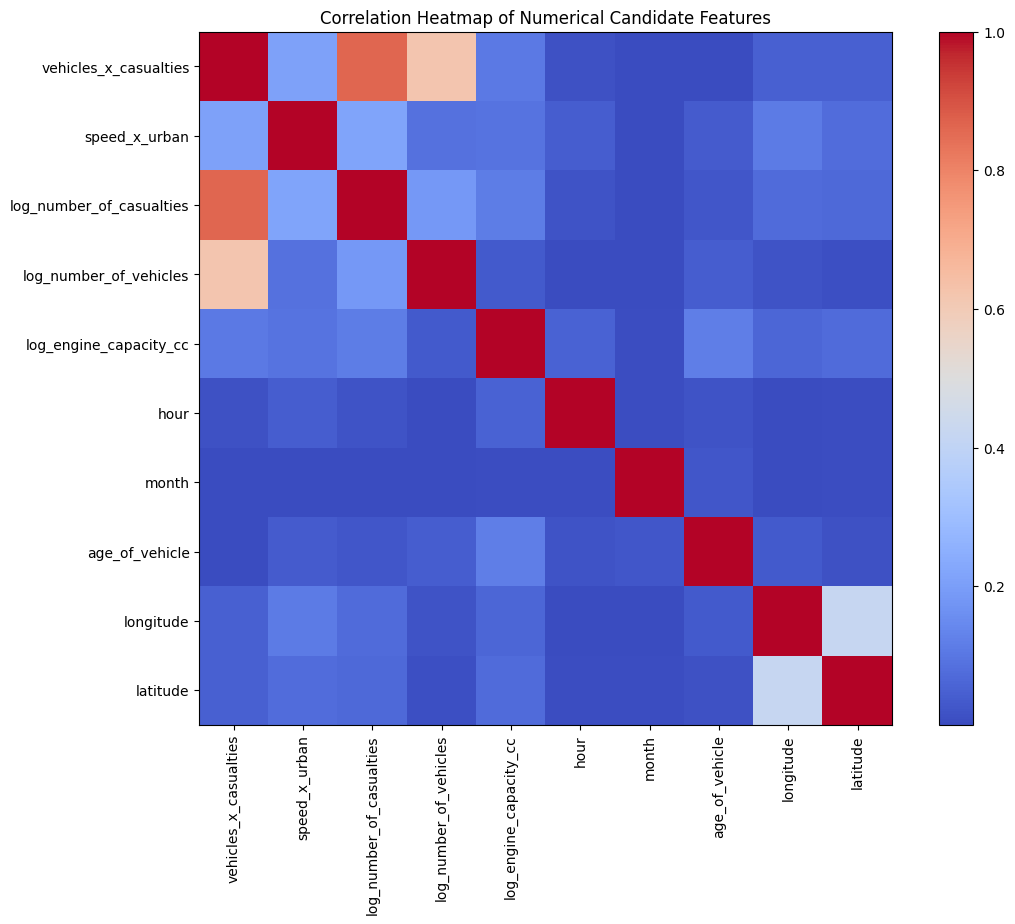

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df_fs is correctly set up from df_fe (as it would have been in the original flow)
df_fs = df_fe.copy()

# Define numeric_features_fs
numeric_features_fs = [
    "vehicles_x_casualties",
    "speed_x_urban",
    "log_number_of_casualties",
    "log_number_of_vehicles",
    "log_engine_capacity_cc",
    "hour",
    "month",
    "age_of_vehicle",
    "longitude",
    "latitude"
]

# Filter to ensure only columns present in df_fs are included
numeric_features_fs = [f for f in numeric_features_fs if f in df_fs.columns]

# Define categorical_features_fs (all other columns excluding target and numeric_features_fs)
categorical_features_fs = [
    col for col in df_fs.columns
    if col not in numeric_features_fs and col != "collision_severity"
]

# Calculate the correlation matrix for the specified numerical features
corr_fs = df_fs[numeric_features_fs].corr(numeric_only=True).abs()

plt.figure(figsize=(12, 9))
plt.imshow(corr_fs, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_fs.columns)), corr_fs.columns, rotation=90)
plt.yticks(range(len(corr_fs.columns)), corr_fs.columns)
plt.title("Correlation Heatmap of Numerical Candidate Features")
plt.show()

### Removing Redundant/Multicollinear Numerical Features

Based on the correlation analysis and prior discussions, `log_number_of_casualties` and `log_number_of_vehicles` are being removed. These features were highly correlated with the engineered interaction term `vehicles_x_casualties`, indicating redundancy and potential multicollinearity. Removing them helps streamline the feature set and avoids issues in downstream modeling, while retaining the combined information in `vehicles_x_casualties`.

In [ ]:
# Remove redundant/multicollinear features from df_fs
features_to_drop_from_fs = [
    'log_number_of_casualties',
    'log_number_of_vehicles'
]

# Ensure only existing columns are dropped
features_to_drop_from_fs = [f for f in features_to_drop_from_fs if f in df_fs.columns]

df_fs = df_fs.drop(columns=features_to_drop_from_fs)

print(f"Removed features from df_fs: {features_to_drop_from_fs}")
print("Shape of df_fs after removal:", df_fs.shape)

Removed features from df_fs: ['log_number_of_casualties', 'log_number_of_vehicles']
Shape of df_fs after removal: (207816, 42)


## 5.2 Variance Inflation Factor (VIF)
VIF is used to measure multicollinearity among numerical predictors. Unlike pairwise correlation, VIF captures how well each variable can be explained by the others jointly.

less than 5 good => automatically keep

5–10 warning

greater than 10 is bad and should be removed

we are going to remove all features > 10

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Filter numeric_features_fs to only include columns currently in df_fs
current_numeric_features = [f for f in numeric_features_fs if f in df_fs.columns]

# Use only numeric features with no missing values and finite values
vif_df_input = df_fs[current_numeric_features].copy()

# Replace inf if any
vif_df_input = vif_df_input.replace([np.inf, -np.inf], np.nan)

# Simple safety fill in case anything remains missing
for col in vif_df_input.columns:
    if vif_df_input[col].isna().sum() > 0:
        vif_df_input[col] = vif_df_input[col].fillna(vif_df_input[col].median())

vif_results = pd.DataFrame({
    "feature": vif_df_input.columns,
    "VIF": [variance_inflation_factor(vif_df_input.values, i) for i in range(vif_df_input.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_results)

,feature,VIF
7,latitude,122.698622
2,log_engine_capacity_cc,109.877607
3,hour,8.190090
0,vehicles_x_casualties,5.468379
4,month,4.788016
5,age_of_vehicle,3.737173
6,longitude,1.862678
1,speed_x_urban,1.490790


In [ ]:
# Remove features with VIF > 10 based on the results above
vif_features_to_drop = ['latitude', 'log_engine_capacity_cc']

# Filter to ensure we only drop what is currently in df_fs
existing_vif_drops = [f for f in vif_features_to_drop if f in df_fs.columns]

df_fs = df_fs.drop(columns=existing_vif_drops)

print(f"Removed due to high VIF (>10): {existing_vif_drops}")
print("New shape of df_fs:", df_fs.shape)

Removed due to high VIF (>10): ['latitude', 'log_engine_capacity_cc']
New shape of df_fs: (207816, 40)


We removed latitude, which tells us how a far a place is from the north or south equator, and we left longitude.
Longitude works normally alone (east/west), and latitude has a very high VIF, meaning it is found in other features, so we have no issues in removing it.

## 5.3 Chi-Squared
This subsection uses statistical method to estimate how strongly individual features are related to the target.

- chi-square for categorical features against the categorical target

- p < 0.05 good to keep, associated to the target
- p ≥ 0.05 weak / consider removing

In [ ]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in categorical_features_fs:
    try:
        contingency = pd.crosstab(df_fs[col], df_fs["collision_severity"])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
            chi2_results.append({
                "feature": col,
                "chi2_statistic": chi2_stat,
                "p_value": p_val,
                "degrees_of_freedom": dof
            })
    except Exception:
        pass

chi2_results_df = pd.DataFrame(chi2_results).sort_values("p_value")
display(chi2_results_df)

,feature,chi2_statistic,p_value,degrees_of_freedom
3,second_road_class,2034.295471,0.000000e+00,12
5,light_conditions,1731.872580,0.000000e+00,6
15,vehicle_direction_from,2362.445725,0.000000e+00,16
10,urban_or_rural_area,3196.609504,0.000000e+00,4
12,vehicle_type,3822.846892,0.000000e+00,38
14,vehicle_manoeuvre,2028.642729,0.000000e+00,30
18,junction_location,2570.777516,0.000000e+00,16
16,vehicle_direction_to,2281.191420,0.000000e+00,16
26,age_band_of_driver,2156.106934,0.000000e+00,20
31,driver_age_group,1754.801183,0.000000e+00,8


### Feature Selection Result Summary
Based on the Chi-Squared test, all remaining categorical features show a significant relationship with the target (p < 0.05). No further categorical features need to be removed at this stage.

## 5.4 Recursive Feature Elimination (RFE)
RFE is a wrapper method that repeatedly fits a model and removes the least useful features until a more compact subset remains.

Here, RFE is applied using logistic regression because it provides an interpretable baseline and aligns well with the later logistic modeling branch.

In [ ]:
print("NaN values in df_fs before RFE:")
display(df_fs.isnull().sum()[df_fs.isnull().sum() > 0].sort_values(ascending=False))

NaN values in df_fs before RFE:


,0
longitude,21


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Use df_fs, which is the current feature-engineered dataset
X_rfe = df_fs.drop(columns=["collision_severity"]).copy()
y_rfe = df_fs["collision_severity"].copy()

# Sample the data to make RFE computationally feasible
X_rfe_sample, _, y_rfe_sample, _ = train_test_split(
    X_rfe,
    y_rfe,
    train_size=20000, # Adjust sample size as needed
    stratify=y_rfe,
    random_state=42
)

# Identify numerical features from the sampled data
numeric_cols_sample = X_rfe_sample.select_dtypes(include=['number']).columns


if 'longitude' in X_rfe_sample.columns:
    if X_rfe_sample['longitude'].isnull().sum() > 0:
        median_val = X_rfe_sample['longitude'].median()
        X_rfe_sample['longitude'] = X_rfe_sample['longitude'].fillna(median_val)
        print(f"Imputed NaN in longitude with median: {median_val}")

scaler = RobustScaler()
X_rfe_scaled = X_rfe_sample.copy()
X_rfe_scaled[numeric_cols_sample] = scaler.fit_transform(X_rfe_sample[numeric_cols_sample])

# Select a manageable number of features
n_features_to_select_rfe = min(20, X_rfe.shape[1])

# Initialize Logistic Regression as the estimator for RFE
logreg_for_rfe = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1,
    multi_class='ovr'
)

# Initialize RFE
rfe = RFE(
    estimator=logreg_for_rfe,
    n_features_to_select=n_features_to_select_rfe,
    step=1
)

# Fit RFE on the scaled sample data
rfe.fit(X_rfe_scaled, y_rfe_sample)

# Create a DataFrame to display the RFE results
rfe_df = pd.DataFrame({
    "feature": X_rfe_sample.columns,
    "selected_by_rfe": rfe.support_,
    "ranking": rfe.ranking_
}).sort_values(["selected_by_rfe", "ranking"], ascending=[False, True])

display(rfe_df)

Imputed NaN in longitude with median: -1.085579


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

,feature,selected_by_rfe,ranking
0,longitude,True,1
1,first_road_class,True,1
3,junction_detail,True,1
4,second_road_class,True,1
6,light_conditions,True,1
8,road_surface_conditions,True,1
9,special_conditions_at_site,True,1
11,urban_or_rural_area,True,1
12,trunk_road_flag,True,1
14,towing_and_articulation,True,1


Imputed missing values in longitude with median: -1.0912

Explained variance ratio per component:
[0.3044 0.2038 0.1521 0.1385 0.1173 0.0839]

Cumulative explained variance:
[0.3044 0.5082 0.6603 0.7988 0.9161 1.    ]


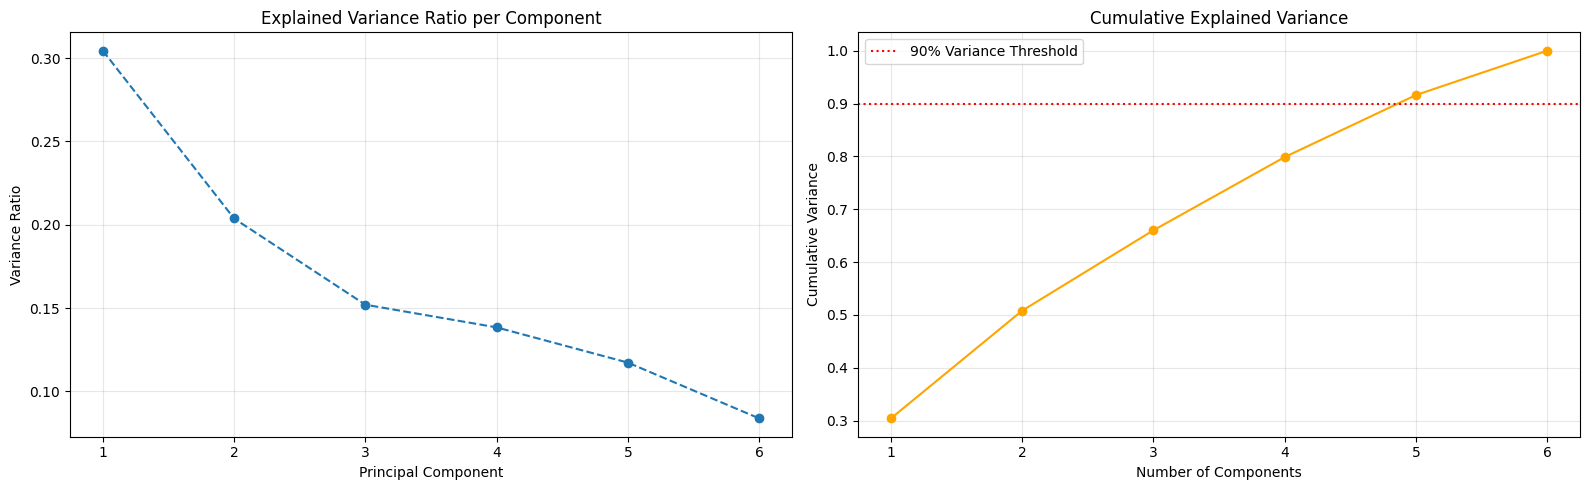

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define numeric features based on the current state of df_fs
numeric_features_fs = [
    "vehicles_x_casualties",
    "speed_x_urban",
    "log_engine_capacity_cc",
    "hour",
    "month",
    "age_of_vehicle",
    "longitude",
    "latitude"
]
# Filter to ensure only columns present in df_fs are included
numeric_features_fs = [f for f in numeric_features_fs if f in df_fs.columns]

X_pca = df_fs[numeric_features_fs].copy()

# Handle missing values and infinite values before PCA
X_pca = X_pca.replace([np.inf, -np.inf], np.nan)

for col in X_pca.columns:
    if X_pca[col].isnull().sum() > 0:
        median_val = X_pca[col].median()
        X_pca[col] = X_pca[col].fillna(median_val)
        print(f"Imputed missing values in {col} with median: {median_val:.4f}")

# Scale the numerical features
scaler = RobustScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA()
pca.fit(X_pca_scaled)

# Display explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\nExplained variance ratio per component:")
print(explained_variance_ratio.round(4))
print("\nCumulative explained variance:")
print(cumulative_variance.round(4))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Individual variance plot
ax1.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
ax1.set_title('Explained Variance Ratio per Component')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Ratio')
ax1.grid(True, alpha=0.3)

# Cumulative variance plot
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='orange')
ax2.axhline(y=0.9, color='r', linestyle=':', label='90% Variance Threshold')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 PCA Interpretation and Decision

The PCA analysis reveals the following:
1. **High Variance Spread**: No single component dominates the variance. The first component only explains ~30%.
2. **Threshold Reached Late**: To capture 90% of the information, we need 5 principal components.
3. **Dimensionality vs. Interpretability**: Since our original numeric feature set is already relatively small (6-8 variables), reducing it to 5 abstract components provides very little computational gain while making the model much harder to interpret.

**Decision**: We will **not** use the PCA components for the final model. Instead, we will retain the original engineered features (like `vehicles_x_casualties`, `speed_x_urban`, etc.) to ensure the final results provide actionable insights for road safety policy.

In [ ]:
# Finalize df_model_final by ensuring it contains the best predictors identified
# We will use the features refined through correlation, VIF, and RFE checks.

# Define the final feature list excluding the target
final_features = [col for col in df_fs.columns if col != 'collision_severity']

df_model_final = df_fs.copy()

print("Final model dataset prepared.")
print(f"Total features for modeling: {len(final_features)}")
print(f"Target variable: collision_severity")
display(df_model_final.head())


Final model dataset prepared.
Total features for modeling: 39
Target variable: collision_severity


,longitude,collision_severity,first_road_class,road_type,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,trunk_road_flag,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,sex_of_driver,age_band_of_driver,propulsion_code,age_of_vehicle,driver_imd_decile,escooter_flag,hour,month,is_weekend,driver_age_group,speed_group,vehicles_x_casualties,speed_x_urban
0,-1.125794,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,2,1,2,7,2,5,7,0,18,5,1,2,2,0.960906,4
1,-1.125794,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,19,2,6,0,0,0,0,0,0,1,1,1,7,2,18,1,0,18,5,1,2,2,0.960906,4
2,-1.125794,3,3,6,0,0,0,1,1,1,4,13,2,2,9,0,4,2,6,0,0,0,0,0,0,0,1,1,7,1,8,5,0,18,5,1,2,2,0.960906,4
3,-1.472891,3,6,6,0,0,0,1,1,1,0,0,2,2,19,0,1,1,5,0,0,0,0,0,0,2,1,1,6,2,5,5,0,15,3,0,1,0,0.480453,0
4,-1.528511,2,4,6,19,6,0,4,1,1,0,0,1,2,9,0,19,8,5,0,1,0,0,0,0,1,1,1,6,2,12,6,0,23,5,1,1,0,0.761500,0


### 5.6 Final Consistency Check and Pruning
Before splitting the data for modeling, we will perform a final check for any administrative variables that might have survived previous steps. We want to ensure the model learns from road conditions and behaviors rather than police reporting areas.

In [ ]:
# Identify any remaining administrative or high-cardinality features that aren't core environmental predictors
final_check_drops = [
    'local_authority_district',
    'police_force',
    'local_authority_highway'
]

# Filter to only those currently in the dataset
existing_final_drops = [f for f in final_check_drops if f in df_model_final.columns]

if existing_final_drops:
    df_model_final = df_model_final.drop(columns=existing_final_drops)
    print(f"Final cleaning: Removed {existing_final_drops}")
else:
    print("No additional administrative features found. Feature set is clean.")

print("Final feature count for Section 6 & 7:", df_model_final.shape[1])

No additional administrative features found. Feature set is clean.
Final feature count for Section 6 & 7: 40


# 6. Final Preprocessing & Assumptions

## According to PCA results, we will need all the features now to explain variance of the target, so we won't remove anything due to RFE & PCA.

#Saved checkpoint

In [ ]:
import os
import pandas as pd

checkpoint_dir = "/content/drive/MyDrive/CMPS 262 Project/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

df_model_final.to_pickle(f"{checkpoint_dir}/df_model_final.pkl")

print("Checkpoint saved successfully.")
print("Saved to:", f"{checkpoint_dir}/df_model_final.pkl")
print("Shape:", df_model_final.shape)

Checkpoint saved successfully.
Saved to: /content/drive/MyDrive/CMPS 262 Project/checkpoints/df_model_final.pkl
Shape: (207816, 40)


##Load the saved checkpoint

In [ ]:
import pandas as pd

checkpoint_path = "/content/drive/MyDrive/CMPS 262 Project/checkpoints/df_model_final.pkl"
df_model_final = pd.read_pickle(checkpoint_path)

print("Checkpoint loaded successfully.")
print("Loaded from:", checkpoint_path)
print("Shape:", df_model_final.shape)

Checkpoint loaded successfully.
Loaded from: /content/drive/MyDrive/CMPS 262 Project/checkpoints/df_model_final.pkl
Shape: (207816, 40)


## 6.1 Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model_final.drop(columns=["collision_severity"])
y = df_model_final["collision_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (166252, 39)
Test shape: (41564, 39)


In [ ]:
X_train = X_train.drop(columns=["has_casualty"], errors="ignore")
X_test = X_test.drop(columns=["has_casualty"], errors="ignore")

In [ ]:
print("Columns currently in X_train:")
print(list(X_train.columns))

print("\nNumber of columns:", len(X_train.columns))

Columns currently in X_train:
['longitude', 'first_road_class', 'road_type', 'junction_detail', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag', 'vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive', 'sex_of_driver', 'age_band_of_driver', 'propulsion_code', 'age_of_vehicle', 'driver_imd_decile', 'escooter_flag', 'hour', 'month', 'is_weekend', 'driver_age_group', 'speed_group', 'vehicles_x_casualties', 'speed_x_urban']

Number of columns: 39


## 6.3 Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Categorical features that are stored as numeric codes but should be dummy-encoded
categorical_cols = [
    "road_type",
    "junction_detail",
    "junction_control",
    "second_road_class",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "vehicle_type",
    "vehicle_manoeuvre",
    "vehicle_direction_from",
    "vehicle_direction_to",
    "first_point_of_impact",
    "sex_of_driver",
    "sex_of_casualty",
    "casualty_type",
    "casualty_class",
    "journey_purpose_of_driver",
    "propulsion_code",
    "vehicle_left_hand_drive",
    "towing_and_articulation",
    "skidding_and_overturning",
    "vehicle_leaving_carriageway",
    "trunk_road_flag",
    "pedestrian_crossing",
    "carriageway_hazards",
    "special_conditions_at_site",
    "junction_location"
]

# Verify which of these categorical columns actually exist in X_train
categorical_cols = [col for col in categorical_cols if col in X_train.columns]

# Initialize OneHotEncoder with handle_unknown='ignore' to fix the ValueError
encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

# Fit on train only
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# Keep the remaining non-categorical columns unchanged
X_train_num = X_train.drop(columns=categorical_cols)
X_test_num = X_test.drop(columns=categorical_cols)

# Concatenate back together
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Categorical columns encoded: {categorical_cols}")
print("Number of categorical features after dummy encoding:", len(encoded_cols))
print("Total shape after encoding:", X_train.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Categorical columns encoded: ['road_type', 'junction_detail', 'second_road_class', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'vehicle_type', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'first_point_of_impact', 'sex_of_driver', 'propulsion_code', 'vehicle_left_hand_drive', 'towing_and_articulation', 'skidding_and_overturning', 'vehicle_leaving_carriageway', 'trunk_road_flag', 'pedestrian_crossing', 'carriageway_hazards', 'special_conditions_at_site', 'junction_location']
Number of categorical features after dummy encoding: 149
Total shape after encoding: (166252, 165)


## 6.5 Class Imbalance - SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np

# working with X_train/X_test.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


# SMOTE does not accept NaN values, so ensure all numerical columns are free of NaNs.
for col in X_train_scaled.columns:
    if X_train_scaled[col].isnull().any():
        median_val = X_train_scaled[col].median()
        X_train_scaled[col] = X_train_scaled[col].fillna(median_val)
        X_test_scaled[col] = X_test_scaled[col].fillna(median_val)
        print(f"Imputed NaN values in {col} with median: {median_val}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE using the (now unscaled) training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution before SMOTE:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))

Imputed NaN values in longitude with median: -1.0900395
Class distribution before SMOTE:
collision_severity
3    0.762427
2    0.220972
1    0.016601
Name: proportion, dtype: float64

Class distribution after SMOTE:
collision_severity
3    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


# Final Missing Check

In [ ]:
print('NaNs in X_train_scaled:\n', X_train_scaled.isnull().sum()[X_train_scaled.isnull().sum() > 0])
print('\nNaNs in X_test_scaled:\n', X_test_scaled.isnull().sum()[X_test_scaled.isnull().sum() > 0])
print('\nNaNs in X_train_balanced:\n', X_train_balanced.isnull().sum()[X_train_balanced.isnull().sum() > 0])
print('\nNaNs in y_train:\n', y_train.isnull().sum())
print('\nNaNs in y_test:\n', y_test.isnull().sum())
print('\nNaNs in y_train_balanced:\n', y_train_balanced.isnull().sum())

NaNs in X_train_scaled:
 Series([], dtype: int64)

NaNs in X_test_scaled:
 Series([], dtype: int64)

NaNs in X_train_balanced:
 Series([], dtype: int64)

NaNs in y_train:
 0

NaNs in y_test:
 0

NaNs in y_train_balanced:
 0


In [ ]:
df_model_final.dropna(subset=['longitude'], inplace=True)
print('NaNs in df_model_final after dropping rows with NaN in longitude:\n', df_model_final.isnull().sum()[df_model_final.isnull().sum() > 0])

NaNs in df_model_final after dropping rows with NaN in longitude:
 Series([], dtype: int64)


In [ ]:
print('NaNs in df_model_final:\n', df_model_final.isnull().sum()[df_model_final.isnull().sum() > 0])

NaNs in df_model_final:
 Series([], dtype: int64)


# Section 7: Modeling and Evaluation

In this section, multiple machine learning models are trained and evaluated to predict collision severity. Each model is trained on the processed training data and evaluated on the test set to ensure a fair and unbiased assessment.

The goal is to compare different modeling approaches, including linear and tree-based models, and analyze their performance using appropriate classification metrics. This allows us to understand how well each model captures the patterns in the data and how they differ in handling class imbalance and feature interactions.

##Checkpoint folder

In [ ]:
import os
import joblib

model_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/model_checkpoints"
os.makedirs(model_ckpt_dir, exist_ok=True)

print("Model checkpoint folder ready:", model_ckpt_dir)

Model checkpoint folder ready: /content/drive/MyDrive/CMPS 262 Project/model_checkpoints


## 7.1 Logistic Regresssion

Accuracy: 0.5420315657780772
Balanced Accuracy: 0.5049928784680907

Classification Report:

              precision    recall  f1-score   support

           1       0.06      0.59      0.10       690
           2       0.26      0.32      0.29      9185
           3       0.83      0.60      0.70     31689

    accuracy                           0.54     41564
   macro avg       0.38      0.50      0.36     41564
weighted avg       0.69      0.54      0.60     41564


Confusion Matrix:



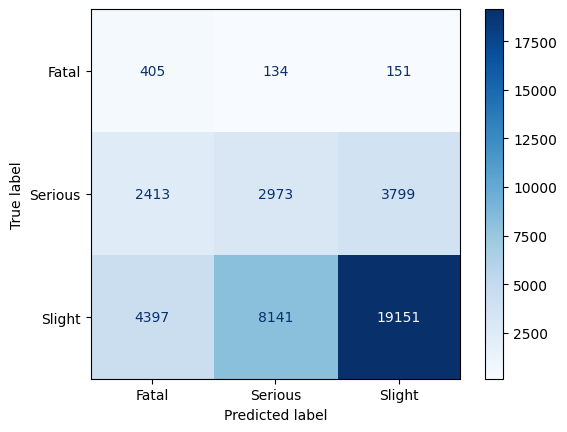

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=2000, n_jobs=-1)

logreg.fit(X_train_balanced, y_train_balanced)

y_pred_lr = logreg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Fatal", "Serious", "Slight"],
    cmap="Blues"
)
plt.show()

## 7.2 Random Forest

Accuracy: 0.8120729477432393
Balanced Accuracy: 0.5201771258603916

Classification Report:

              precision    recall  f1-score   support

           1       0.94      0.33      0.49       690
           2       0.83      0.24      0.37      9185
           3       0.81      0.99      0.89     31689

    accuracy                           0.81     41564
   macro avg       0.86      0.52      0.58     41564
weighted avg       0.82      0.81      0.77     41564


Confusion Matrix:



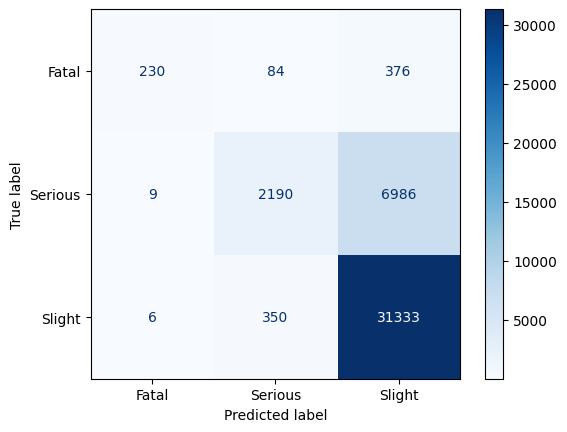

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Fatal", "Serious", "Slight"],
    cmap="Blues"
)
plt.show()

In [ ]:
joblib.dump(rf, f"{model_ckpt_dir}/rf.pkl")
joblib.dump(y_pred_rf, f"{model_ckpt_dir}/y_pred_rf.pkl")

print("Random Forest checkpoint saved.")

Random Forest checkpoint saved.


## 7.3 Random Forest Feature Importance

In [ ]:
import pandas as pd

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

display(rf_importance.head(20))

,feature,importance
14,vehicles_x_casualties,0.062066
0,longitude,0.042603
9,hour,0.036770
6,age_of_vehicle,0.032355
10,month,0.030235
97,first_point_of_impact_1,0.027781
80,vehicle_manoeuvre_19,0.027683
7,driver_imd_decile,0.026540
45,urban_or_rural_area_2,0.024994
157,junction_location_1,0.023999


In [ ]:
joblib.dump(rf_importance, f"{model_ckpt_dir}/rf_importance.pkl")

print("Random Forest importance table saved.")

Random Forest importance table saved.


## 7.4 XGBoost

Accuracy: 0.7698007891444519
Balanced Accuracy: 0.46251974449547667

Classification Report:

              precision    recall  f1-score   support

           1       0.25      0.30      0.27       690
           2       0.58      0.12      0.20      9185
           3       0.79      0.97      0.87     31689

    accuracy                           0.77     41564
   macro avg       0.54      0.46      0.45     41564
weighted avg       0.73      0.77      0.71     41564


Confusion Matrix:



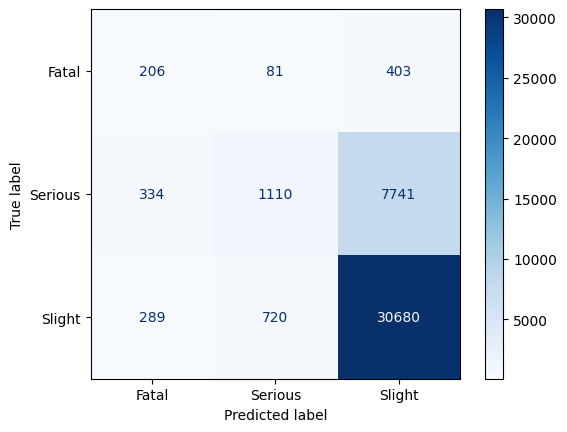

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score

# Encode y only for XGBoost
le_xgb = LabelEncoder()

y_train_balanced_xgb = le_xgb.fit_transform(y_train_balanced)
y_test_xgb = le_xgb.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb.fit(X_train_balanced, y_train_balanced_xgb)

y_pred_xgb_encoded = xgb.predict(X_test_scaled)
y_pred_xgb = le_xgb.inverse_transform(y_pred_xgb_encoded)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["Fatal", "Serious", "Slight"],
    cmap="Blues"
)
plt.show()

In [ ]:
joblib.dump(xgb, f"{model_ckpt_dir}/xgb.pkl")
joblib.dump(le_xgb, f"{model_ckpt_dir}/le_xgb.pkl")
joblib.dump(y_pred_xgb, f"{model_ckpt_dir}/y_pred_xgb.pkl")

print("XGBoost checkpoint saved.")

XGBoost checkpoint saved.


## 7.5 Balanced Random Forest

Accuracy: 0.6183476085073621
Balanced Accuracy: 0.6058846222291482

Classification Report:

              precision    recall  f1-score   support

           1       0.14      0.63      0.23       690
           2       0.34      0.54      0.42      9185
           3       0.86      0.64      0.73     31689

    accuracy                           0.62     41564
   macro avg       0.44      0.61      0.46     41564
weighted avg       0.73      0.62      0.66     41564


Confusion Matrix:



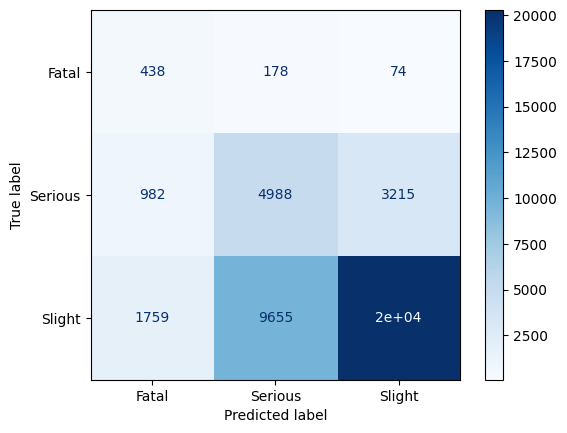

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train, y_train)

y_pred_brf = brf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_brf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_brf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_brf))

print("\nConfusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_brf,
    display_labels=["Fatal", "Serious", "Slight"],
    cmap="Blues"
)
plt.show()

In [ ]:
joblib.dump(brf, f"{model_ckpt_dir}/brf.pkl")
joblib.dump(y_pred_brf, f"{model_ckpt_dir}/y_pred_brf.pkl")

print("Balanced Random Forest checkpoint saved.")

Balanced Random Forest checkpoint saved.


##Loading checkpoint

In [ ]:
import joblib

model_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/model_checkpoints"

logreg = joblib.load(f"{model_ckpt_dir}/logreg.pkl")
y_pred_lr = joblib.load(f"{model_ckpt_dir}/y_pred_lr.pkl")

rf = joblib.load(f"{model_ckpt_dir}/rf.pkl")
y_pred_rf = joblib.load(f"{model_ckpt_dir}/y_pred_rf.pkl")

xgb = joblib.load(f"{model_ckpt_dir}/xgb.pkl")
le_xgb = joblib.load(f"{model_ckpt_dir}/le_xgb.pkl")
y_pred_xgb = joblib.load(f"{model_ckpt_dir}/y_pred_xgb.pkl")

brf = joblib.load(f"{model_ckpt_dir}/brf.pkl")
y_pred_brf = joblib.load(f"{model_ckpt_dir}/y_pred_brf.pkl")

print("All model checkpoints loaded successfully.")

All model checkpoints loaded successfully.


## 7.6 Comparison Table

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import pandas as pd
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Balanced RF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_brf)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_brf)
    ]
})

display(results)

,Model,Accuracy,Balanced Accuracy
0,Logistic Regression,0.542032,0.504993
1,Random Forest,0.812073,0.520177
2,XGBoost,0.769801,0.462520
3,Balanced RF,0.618348,0.605885


## 7.7 Statistical Comparison of Models

Point estimates alone are not enough to conclude that one model is truly better than another, especially in an imbalanced multiclass classification problem.

In this section, the four trained models are compared more rigorously using:
- Macro-F1 as the main metric
- Balanced Accuracy as a supporting metric
- Paired bootstrap resampling on the same test set
- 95% confidence intervals
- Pairwise significance testing with Holm correction

This approach is more reliable than comparing only one F1 value per model, because it quantifies uncertainty and tests whether the observed differences are likely to be real or could have occurred by chance.

### 7.7.1 Why Macro-F1 and Balanced Accuracy?
The dataset is imbalanced, with slight collisions dominating the target distribution and fatal collisions being rare.

For this reason:
- Macro-F1 is used as the main comparison metric because it gives equal weight to all classes
- Balanced Accuracy is used as a supporting metric because it averages recall across classes and is more appropriate than raw accuracy in imbalanced settings

In addition, per-class recall remains important, especially for the rare fatal and serious classes.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, balanced_accuracy_score
from itertools import combinations
from statsmodels.stats.multitest import multipletests

### 7.7.2 Collect the Final Test Predictions
Only the final test predictions are needed here. The full notebook does not need to be rerun.

The following objects should already exist from Section 7:
- `y_test`
- `y_pred_lr`
- `y_pred_rf`
- `y_pred_xgb`
- `y_pred_brf`

In [ ]:
# Store predictions in one dictionary
model_predictions = {
    "Logistic Regression": np.array(y_pred_lr),
    "Random Forest": np.array(y_pred_rf),
    "XGBoost": np.array(y_pred_xgb),
    "Balanced Random Forest": np.array(y_pred_brf)
}

# Convert y_test to a clean numpy array
y_true = np.array(y_test)

print("Models available for statistical comparison:")
print(list(model_predictions.keys()))
print("Test set size:", len(y_true))

Models available for statistical comparison:
['Logistic Regression', 'Random Forest', 'XGBoost', 'Balanced Random Forest']
Test set size: 41564


### 7.7.3 Bootstrap Confidence Intervals per Model
For each model, the test set is resampled with replacement many times. For each resample, Macro-F1 and Balanced Accuracy are recomputed.

This gives:
- a bootstrap distribution for each metric
- a mean estimate
- a 95% confidence interval

In [ ]:
def bootstrap_model_metrics(y_true, y_pred, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    macro_f1_scores = []
    balanced_acc_scores = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]

        macro_f1_scores.append(f1_score(y_true_sample, y_pred_sample, average="macro"))
        balanced_acc_scores.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    macro_f1_scores = np.array(macro_f1_scores)
    balanced_acc_scores = np.array(balanced_acc_scores)

    return {
        "macro_f1_mean": macro_f1_scores.mean(),
        "macro_f1_ci_low": np.percentile(macro_f1_scores, 2.5),
        "macro_f1_ci_high": np.percentile(macro_f1_scores, 97.5),
        "balanced_acc_mean": balanced_acc_scores.mean(),
        "balanced_acc_ci_low": np.percentile(balanced_acc_scores, 2.5),
        "balanced_acc_ci_high": np.percentile(balanced_acc_scores, 97.5),
        "macro_f1_distribution": macro_f1_scores,
        "balanced_acc_distribution": balanced_acc_scores
    }

In [ ]:
bootstrap_results = {}

for model_name, preds in model_predictions.items():
    bootstrap_results[model_name] = bootstrap_model_metrics(y_true, preds, n_bootstrap=2000, random_state=42)

bootstrap_summary = pd.DataFrame({
    "Model": list(bootstrap_results.keys()),
    "Macro-F1 Mean": [bootstrap_results[m]["macro_f1_mean"] for m in bootstrap_results],
    "Macro-F1 CI Low": [bootstrap_results[m]["macro_f1_ci_low"] for m in bootstrap_results],
    "Macro-F1 CI High": [bootstrap_results[m]["macro_f1_ci_high"] for m in bootstrap_results],
    "Balanced Accuracy Mean": [bootstrap_results[m]["balanced_acc_mean"] for m in bootstrap_results],
    "Balanced Accuracy CI Low": [bootstrap_results[m]["balanced_acc_ci_low"] for m in bootstrap_results],
    "Balanced Accuracy CI High": [bootstrap_results[m]["balanced_acc_ci_high"] for m in bootstrap_results],
})

display(bootstrap_summary.sort_values("Macro-F1 Mean", ascending=False))

,Model,Macro-F1 Mean,Macro-F1 CI Low,Macro-F1 CI High,Balanced Accuracy Mean,Balanced Accuracy CI Low,Balanced Accuracy CI High
1,Random Forest,0.584379,0.570708,0.597755,0.520234,0.508631,0.532400
3,Balanced Random Forest,0.458643,0.451658,0.465532,0.605938,0.593284,0.618306
2,XGBoost,0.447198,0.436971,0.457826,0.462617,0.451492,0.474207
0,Logistic Regression,0.364190,0.359771,0.368750,0.505145,0.492805,0.517678


In [ ]:
import os
import joblib

bootstrap_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/bootstrap_checkpoints"
os.makedirs(bootstrap_ckpt_dir, exist_ok=True)

joblib.dump(bootstrap_results, f"{bootstrap_ckpt_dir}/bootstrap_results.pkl")
joblib.dump(bootstrap_summary, f"{bootstrap_ckpt_dir}/bootstrap_summary.pkl")

print("Bootstrap results saved successfully.")
print("Saved to:", bootstrap_ckpt_dir)

Bootstrap results saved successfully.
Saved to: /content/drive/MyDrive/CMPS 262 Project/bootstrap_checkpoints


##Load checkpoint

In [ ]:
import joblib

bootstrap_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/bootstrap_checkpoints"

bootstrap_results = joblib.load(f"{bootstrap_ckpt_dir}/bootstrap_results.pkl")
bootstrap_summary = joblib.load(f"{bootstrap_ckpt_dir}/bootstrap_summary.pkl")

print("Bootstrap results loaded successfully.")
print("Loaded from:", bootstrap_ckpt_dir)

display(bootstrap_summary.sort_values("Macro-F1 Mean", ascending=False))

Bootstrap results loaded successfully.
Loaded from: /content/drive/MyDrive/CMPS 262 Project/bootstrap_checkpoints


,Model,Macro-F1 Mean,Macro-F1 CI Low,Macro-F1 CI High,Balanced Accuracy Mean,Balanced Accuracy CI Low,Balanced Accuracy CI High
1,Random Forest,0.546094,0.532216,0.559386,0.492263,0.481293,0.503347
3,Balanced Random Forest,0.466448,0.459831,0.473204,0.613922,0.601819,0.626625
2,XGBoost,0.461951,0.450729,0.472705,0.465562,0.454054,0.476563
0,Logistic Regression,0.390856,0.386033,0.395682,0.560511,0.548953,0.572775


### 7.7.4 Pairwise Bootstrap Comparisons
To test whether one model is meaningfully better than another, pairwise bootstrap comparisons are computed on Macro-F1 differences.

For each pair:
- the test set is resampled with replacement
- the Macro-F1 difference is computed
- a 95% confidence interval for the difference is produced
- a bootstrap p-value is estimated

Interpretation:
- if the 95% CI excludes 0, the difference is supported
- if the CI includes 0, the two models are not clearly separable

In [ ]:
def bootstrap_difference_test(y_true, y_pred_a, y_pred_b, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_sample = y_true[idx]
        y_a_sample = y_pred_a[idx]
        y_b_sample = y_pred_b[idx]

        score_a = f1_score(y_true_sample, y_a_sample, average="macro")
        score_b = f1_score(y_true_sample, y_b_sample, average="macro")

        diffs.append(score_a - score_b)

    diffs = np.array(diffs)

    # Two-sided bootstrap p-value approximation
    p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))

    return {
        "mean_diff": diffs.mean(),
        "ci_low": np.percentile(diffs, 2.5),
        "ci_high": np.percentile(diffs, 97.5),
        "p_value": min(p_value, 1.0)
    }

In [ ]:
pairwise_results = []

for model_a, model_b in combinations(model_predictions.keys(), 2):
    result = bootstrap_difference_test(
        y_true,
        model_predictions[model_a],
        model_predictions[model_b],
        n_bootstrap=2000,
        random_state=42
    )

    pairwise_results.append({
        "Model A": model_a,
        "Model B": model_b,
        "Mean Macro-F1 Difference (A-B)": result["mean_diff"],
        "CI Low": result["ci_low"],
        "CI High": result["ci_high"],
        "Raw p-value": result["p_value"]
    })

pairwise_df = pd.DataFrame(pairwise_results)
display(pairwise_df)

,Model A,Model B,Mean Macro-F1 Difference (A-B),CI Low,CI High,Raw p-value
0,Logistic Regression,Random Forest,-0.220190,-0.234004,-0.205853,0.000
1,Logistic Regression,XGBoost,-0.083009,-0.092956,-0.072992,0.000
2,Logistic Regression,Balanced Random Forest,-0.094453,-0.100238,-0.088502,0.000
3,Random Forest,XGBoost,0.137181,0.124695,0.149939,0.000
4,Random Forest,Balanced Random Forest,0.125736,0.112147,0.138821,0.000
5,XGBoost,Balanced Random Forest,-0.011444,-0.021276,-0.001500,0.027


### 7.7.5 Holm Correction for Multiple Comparisons
Since six pairwise comparisons are being tested, the p-values should be corrected to reduce the chance of false positives.

Holm correction is used here because it is a standard and practical family-wise error control method.

In [ ]:
holm_results = multipletests(pairwise_df["Raw p-value"], method="holm")

pairwise_df["Holm-corrected p-value"] = holm_results[1]
pairwise_df["Reject Null after Holm?"] = holm_results[0]

display(pairwise_df.sort_values("Holm-corrected p-value"))

,Model A,Model B,Mean Macro-F1 Difference (A-B),CI Low,CI High,Raw p-value,Holm-corrected p-value,Reject Null after Holm?
0,Logistic Regression,Random Forest,-0.220190,-0.234004,-0.205853,0.000,0.000,True
1,Logistic Regression,XGBoost,-0.083009,-0.092956,-0.072992,0.000,0.000,True
2,Logistic Regression,Balanced Random Forest,-0.094453,-0.100238,-0.088502,0.000,0.000,True
3,Random Forest,XGBoost,0.137181,0.124695,0.149939,0.000,0.000,True
4,Random Forest,Balanced Random Forest,0.125736,0.112147,0.138821,0.000,0.000,True
5,XGBoost,Balanced Random Forest,-0.011444,-0.021276,-0.001500,0.027,0.027,True


In [ ]:
pairwise_df_pretty = pairwise_df.copy()

pairwise_df_pretty["Raw p-value (formatted)"] = pairwise_df_pretty["Raw p-value"].map(lambda x: f"{x:.3e}")
pairwise_df_pretty["Holm-corrected p-value (formatted)"] = pairwise_df_pretty["Holm-corrected p-value"].map(lambda x: f"{x:.3e}")

display(
    pairwise_df_pretty[
        [
            "Model A",
            "Model B",
            "Mean Macro-F1 Difference (A-B)",
            "CI Low",
            "CI High",
            "Raw p-value (formatted)",
            "Holm-corrected p-value (formatted)",
            "Reject Null after Holm?"
        ]
    ].sort_values("Holm-corrected p-value (formatted)")
)

,Model A,Model B,Mean Macro-F1 Difference (A-B),CI Low,CI High,Raw p-value (formatted),Holm-corrected p-value (formatted),Reject Null after Holm?
0,Logistic Regression,Random Forest,-0.220190,-0.234004,-0.205853,0.000e+00,0.000e+00,True
1,Logistic Regression,XGBoost,-0.083009,-0.092956,-0.072992,0.000e+00,0.000e+00,True
2,Logistic Regression,Balanced Random Forest,-0.094453,-0.100238,-0.088502,0.000e+00,0.000e+00,True
3,Random Forest,XGBoost,0.137181,0.124695,0.149939,0.000e+00,0.000e+00,True
4,Random Forest,Balanced Random Forest,0.125736,0.112147,0.138821,0.000e+00,0.000e+00,True
5,XGBoost,Balanced Random Forest,-0.011444,-0.021276,-0.001500,2.700e-02,2.700e-02,True


### 7.7.6 Statistical Interpretation
The purpose of this subsection is to identify:
- which model has the highest Macro-F1 on average
- whether that advantage is statistically supported
- which models are statistically tied

A model should only be declared clearly superior if:
- it has the strongest mean Macro-F1
- its confidence interval is stable
- and its advantage over competitors remains significant after Holm correction

If top models are not significantly different, then the final decision should be based on practical criteria such as:
- recall on fatal and serious collisions
- model stability
- interpretability
- computational cost

In [ ]:
# Compact summary for direct interpretation
best_macro_model = bootstrap_summary.sort_values("Macro-F1 Mean", ascending=False).iloc[0]

print("Best point-estimate model by Macro-F1:")
display(best_macro_model.to_frame().T)

print("\nPairwise comparisons after Holm correction:")
display(pairwise_df.sort_values("Holm-corrected p-value"))

Best point-estimate model by Macro-F1:


,Model,Macro-F1 Mean,Macro-F1 CI Low,Macro-F1 CI High,Balanced Accuracy Mean,Balanced Accuracy CI Low,Balanced Accuracy CI High
1,Random Forest,0.584379,0.570708,0.597755,0.520234,0.508631,0.5324



Pairwise comparisons after Holm correction:


,Model A,Model B,Mean Macro-F1 Difference (A-B),CI Low,CI High,Raw p-value,Holm-corrected p-value,Reject Null after Holm?
0,Logistic Regression,Random Forest,-0.220190,-0.234004,-0.205853,0.000,0.000,True
1,Logistic Regression,XGBoost,-0.083009,-0.092956,-0.072992,0.000,0.000,True
2,Logistic Regression,Balanced Random Forest,-0.094453,-0.100238,-0.088502,0.000,0.000,True
3,Random Forest,XGBoost,0.137181,0.124695,0.149939,0.000,0.000,True
4,Random Forest,Balanced Random Forest,0.125736,0.112147,0.138821,0.000,0.000,True
5,XGBoost,Balanced Random Forest,-0.011444,-0.021276,-0.001500,0.027,0.027,True


### 7.7.7 What This Adds to the Project
This statistical comparison improves the project in three ways:

1. It avoids choosing a winner based only on one point estimate  
2. It quantifies uncertainty through confidence intervals  
3. It checks whether observed differences between models are large enough to be considered meaningful

This makes the final model comparison more rigorous and more defensible academically.

##7.7.8 Final Interpretation of comparison between models
The statistical comparison confirms that Random Forest is the strongest overall model under the chosen main metric, Macro-F1. Its estimated Macro-F1 was higher than that of Logistic Regression, XGBoost, and Balanced Random Forest, and these differences remained statistically significant after Holm correction. In contrast, XGBoost and Balanced Random Forest were not significantly different from each other. This means that Random Forest is the most defensible final choice for this project when class-balanced predictive performance is prioritized.

## 7.8 Threshold Tuning for Random Forest

Random Forest was selected as the strongest overall model based on Macro-F1. However, the default decision rule of a classifier is not always optimal, especially in an imbalanced multiclass problem.

In this project, the most important classes are the severe ones:
- Fatal
- Serious

Therefore, instead of changing the model family, we improve the decision rule by tuning class-probability thresholds:
- one threshold for **fatal**
- one threshold for **serious**
- **slight** becomes the fallback class

This allows the model to prioritize severe cases more directly while still controlling false alarms.

### 7.8.1 Validation-Based Threshold Tuning
Thresholds should not be chosen on the final test set. To avoid overfitting, the training data is split again into:
- inner training set
- validation set

The Random Forest is fitted on the inner training data, balanced using SMOTE, and thresholds are chosen on the validation set only.

After the best thresholds are selected, the Random Forest is refit on the full training data and evaluated once on the untouched test set.

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Inner split from the already prepared training set
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# SMOTE only on inner training set
smote_inner = SMOTE(random_state=42)
X_train_inner_balanced, y_train_inner_balanced = smote_inner.fit_resample(X_train_inner, y_train_inner)

# Fit a fresh RF for threshold tuning
rf_tune = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_tune.fit(X_train_inner_balanced, y_train_inner_balanced)

# Validation probabilities
val_proba = rf_tune.predict_proba(X_val)
rf_tune.classes_

array([1, 2, 3])

##Save checkpoint

In [ ]:
import os
import joblib

threshold_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/threshold_checkpoints"
os.makedirs(threshold_ckpt_dir, exist_ok=True)

joblib.dump(X_train_inner, f"{threshold_ckpt_dir}/X_train_inner.pkl")
joblib.dump(X_val, f"{threshold_ckpt_dir}/X_val.pkl")
joblib.dump(y_train_inner, f"{threshold_ckpt_dir}/y_train_inner.pkl")
joblib.dump(y_val, f"{threshold_ckpt_dir}/y_val.pkl")

joblib.dump(X_train_inner_balanced, f"{threshold_ckpt_dir}/X_train_inner_balanced.pkl")
joblib.dump(y_train_inner_balanced, f"{threshold_ckpt_dir}/y_train_inner_balanced.pkl")

joblib.dump(rf_tune, f"{threshold_ckpt_dir}/rf_tune.pkl")
joblib.dump(val_proba, f"{threshold_ckpt_dir}/val_proba.pkl")
joblib.dump(rf_tune.classes_, f"{threshold_ckpt_dir}/rf_tune_classes.pkl")

print("Threshold-tuning checkpoint saved successfully.")
print("Saved to:", threshold_ckpt_dir)
print("Validation set size:", len(y_val))

Threshold-tuning checkpoint saved successfully.
Saved to: /content/drive/MyDrive/CMPS 262 Project/threshold_checkpoints
Validation set size: 33251


##Load checkpoint

In [ ]:
import joblib

threshold_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/threshold_checkpoints"

X_train_inner = joblib.load(f"{threshold_ckpt_dir}/X_train_inner.pkl")
X_val = joblib.load(f"{threshold_ckpt_dir}/X_val.pkl")
y_train_inner = joblib.load(f"{threshold_ckpt_dir}/y_train_inner.pkl")
y_val = joblib.load(f"{threshold_ckpt_dir}/y_val.pkl")

X_train_inner_balanced = joblib.load(f"{threshold_ckpt_dir}/X_train_inner_balanced.pkl")
y_train_inner_balanced = joblib.load(f"{threshold_ckpt_dir}/y_train_inner_balanced.pkl")

rf_tune = joblib.load(f"{threshold_ckpt_dir}/rf_tune.pkl")
val_proba = joblib.load(f"{threshold_ckpt_dir}/val_proba.pkl")
rf_tune_classes_ = joblib.load(f"{threshold_ckpt_dir}/rf_tune_classes.pkl")

print("Threshold-tuning checkpoint loaded successfully.")
print("Loaded from:", threshold_ckpt_dir)
print("Validation set size:", len(y_val))
print("Classes:", rf_tune_classes_)

Threshold-tuning checkpoint loaded successfully.
Loaded from: /content/drive/MyDrive/CMPS 262 Project/threshold_checkpoints
Validation set size: 33251
Classes: [1 2 3]


### 7.8.2 Choose Thresholds Using Precision-Recall Logic
The tuning objective is different for the two severe classes:

- **Fatal**: prioritize recall more strongly, because missing fatal cases is costly  
  → choose threshold using **F2-score**

- **Serious**: use a more balanced precision-recall tradeoff  
  → choose threshold using **F1-score**

This is more appropriate than tuning from ROC-AUC, because threshold choice should reflect the project objective directly.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

# Map class labels to probability columns
class_to_index = {cls: i for i, cls in enumerate(rf_tune.classes_)}

fatal_label = 1
serious_label = 2
slight_label = 3

fatal_idx = class_to_index[fatal_label]
serious_idx = class_to_index[serious_label]

p_fatal_val = val_proba[:, fatal_idx]
p_serious_val = val_proba[:, serious_idx]

y_val_fatal = (y_val == fatal_label).astype(int)
y_val_serious = (y_val == serious_label).astype(int)

In [ ]:
def best_threshold_from_pr(y_true_binary, probas, beta=1.0):
    precision, recall, thresholds = precision_recall_curve(y_true_binary, probas)

    # precision_recall_curve returns one extra precision/recall value
    precision = precision[:-1]
    recall = recall[:-1]

    beta_sq = beta ** 2
    scores = (1 + beta_sq) * (precision * recall) / ((beta_sq * precision) + recall + 1e-12)

    best_idx = np.nanargmax(scores)

    return {
        "best_threshold": thresholds[best_idx],
        "best_score": scores[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

fatal_threshold_result = best_threshold_from_pr(y_val_fatal, p_fatal_val, beta=2.0)
serious_threshold_result = best_threshold_from_pr(y_val_serious, p_serious_val, beta=1.0)

fatal_threshold_result, serious_threshold_result

({'best_threshold': np.float64(0.155),
  'best_score': np.float64(0.4254930606280006),
  'precision': np.float64(0.439622641509434),
  'recall': np.float64(0.4221014492753623)},
 {'best_threshold': np.float64(0.285),
  'best_score': np.float64(0.48941413688760793),
  'precision': np.float64(0.41585760517799353),
  'recall': np.float64(0.5945835601524224)})

### 7.8.3 Final Multiclass Decision Rule
Once the thresholds are chosen, predictions are made using this rule:

- if `P(fatal) >= t_fatal` → predict fatal  
- else if `P(serious) >= t_serious` → predict serious  
- else → predict slight

This makes severe classes explicit priorities, while slight becomes the fallback class.

In [ ]:
t_fatal = fatal_threshold_result["best_threshold"]
t_serious = serious_threshold_result["best_threshold"]

print("Chosen fatal threshold:", round(t_fatal, 4))
print("Chosen serious threshold:", round(t_serious, 4))

print("\nFatal threshold validation summary:")
print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in fatal_threshold_result.items()})

print("\nSerious threshold validation summary:")
print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in serious_threshold_result.items()})

Chosen fatal threshold: 0.155
Chosen serious threshold: 0.285

Fatal threshold validation summary:
{'best_threshold': np.float64(0.155), 'best_score': np.float64(0.4255), 'precision': np.float64(0.4396), 'recall': np.float64(0.4221)}

Serious threshold validation summary:
{'best_threshold': np.float64(0.285), 'best_score': np.float64(0.4894), 'precision': np.float64(0.4159), 'recall': np.float64(0.5946)}


In [ ]:
def apply_severity_thresholds(proba_matrix, classes, t_fatal, t_serious):
    class_to_index = {cls: i for i, cls in enumerate(classes)}

    fatal_idx = class_to_index[1]
    serious_idx = class_to_index[2]

    p_fatal = proba_matrix[:, fatal_idx]
    p_serious = proba_matrix[:, serious_idx]

    preds = []

    for pf, ps in zip(p_fatal, p_serious):
        if pf >= t_fatal:
            preds.append(1)  # Fatal
        elif ps >= t_serious:
            preds.append(2)  # Serious
        else:
            preds.append(3)  # Slight fallback

    return np.array(preds)

### 7.8.4 Refit Random Forest on the Full Training Data
After the thresholds are chosen on validation data, the Random Forest is refit on the full training data and evaluated on the untouched test set.

This ensures that:
- threshold tuning is validation-based
- the final test set remains the final evaluation reference

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Refit RF on the full training data (balanced version already prepared earlier)
rf_final_tuned = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final_tuned.fit(X_train_balanced, y_train_balanced)

# Default predictions on test set
y_pred_rf_default = rf_final_tuned.predict(X_test_scaled)

# Tuned predictions on test set
test_proba_rf = rf_final_tuned.predict_proba(X_test_scaled)
y_pred_rf_tuned = apply_severity_thresholds(
    test_proba_rf,
    rf_final_tuned.classes_,
    t_fatal=t_fatal,
    t_serious=t_serious
)

##Save checkpoint

In [ ]:
import os
import joblib

rf_threshold_dir = "/content/drive/MyDrive/CMPS 262 Project/rf_threshold_results"
os.makedirs(rf_threshold_dir, exist_ok=True)

joblib.dump(rf_final_tuned, f"{rf_threshold_dir}/rf_final_tuned.pkl")
joblib.dump(test_proba_rf, f"{rf_threshold_dir}/test_proba_rf.pkl")
joblib.dump(y_pred_rf_default, f"{rf_threshold_dir}/y_pred_rf_default.pkl")
joblib.dump(y_pred_rf_tuned, f"{rf_threshold_dir}/y_pred_rf_tuned.pkl")
joblib.dump(t_fatal, f"{rf_threshold_dir}/t_fatal.pkl")
joblib.dump(t_serious, f"{rf_threshold_dir}/t_serious.pkl")

print("Final threshold-tuned RF results saved successfully.")
print("Saved to:", rf_threshold_dir)

Final threshold-tuned RF results saved successfully.
Saved to: /content/drive/MyDrive/CMPS 262 Project/rf_threshold_results


##Load checkpoint

In [ ]:
import joblib

rf_threshold_dir = "/content/drive/MyDrive/CMPS 262 Project/rf_threshold_results"

rf_final_tuned = joblib.load(f"{rf_threshold_dir}/rf_final_tuned.pkl")
test_proba_rf = joblib.load(f"{rf_threshold_dir}/test_proba_rf.pkl")
y_pred_rf_default = joblib.load(f"{rf_threshold_dir}/y_pred_rf_default.pkl")
y_pred_rf_tuned = joblib.load(f"{rf_threshold_dir}/y_pred_rf_tuned.pkl")
t_fatal = joblib.load(f"{rf_threshold_dir}/t_fatal.pkl")
t_serious = joblib.load(f"{rf_threshold_dir}/t_serious.pkl")

print("Final threshold-tuned RF results loaded successfully.")
print("Fatal threshold:", t_fatal)
print("Serious threshold:", t_serious)

##Note

It's important to note that the random forest model was not tuned, only the thresholds were tuned.

##Looking at the new model's statistics

Tuned Random Forest Performance

Accuracy: 0.726903
Balanced Accuracy: 0.596902
Macro-F1: 0.587456
Weighted-F1: 0.740146

Classification Report:

              precision    recall  f1-score   support

       Fatal       0.47      0.43      0.45       690
     Serious       0.43      0.59      0.50      9185
      Slight       0.87      0.77      0.82     31689

    accuracy                           0.73     41564
   macro avg       0.59      0.60      0.59     41564
weighted avg       0.76      0.73      0.74     41564


Confusion Matrix:



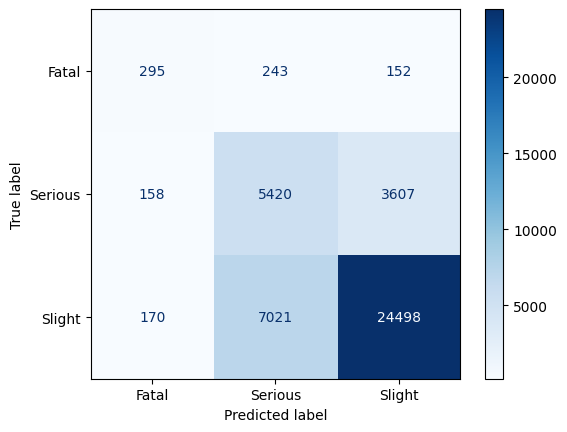

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Tuned Random Forest Performance\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf_tuned), 6))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_rf_tuned), 6))
print("Macro-F1:", round(f1_score(y_test, y_pred_rf_tuned, average="macro"), 6))
print("Weighted-F1:", round(f1_score(y_test, y_pred_rf_tuned, average="weighted"), 6))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned, target_names=["Fatal", "Serious", "Slight"]))

print("\nConfusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    display_labels=["Fatal", "Serious", "Slight"],
    cmap="Blues"
)
plt.show()

### 7.8.5 Compare Default RF vs Tuned RF
The tuned Random Forest is compared against the original default decision rule using:
- Macro-F1
- Balanced Accuracy
- Classification report
- Confusion matrix

This shows whether threshold tuning actually improves the severe-class tradeoff.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, f1_score
import pandas as pd

rf_compare = pd.DataFrame({
    "Version": ["Default RF", "Tuned RF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_default),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_rf_default),
        balanced_accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Macro-F1": [
        f1_score(y_test, y_pred_rf_default, average="macro"),
        f1_score(y_test, y_pred_rf_tuned, average="macro")
    ],
    "Weighted-F1": [
        f1_score(y_test, y_pred_rf_default, average="weighted"),
        f1_score(y_test, y_pred_rf_tuned, average="weighted")
    ]
})

display(rf_compare.round(6))

,Version,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
0,Default RF,0.812073,0.520177,0.584409,0.768943
1,Tuned RF,0.726903,0.596902,0.587456,0.740146


,Version,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
0,Default RF,0.812073,0.520177,0.584409,0.768943
1,Tuned RF,0.726903,0.596902,0.587456,0.740146



Default RF - Classification Report:

              precision    recall  f1-score   support

       Fatal       0.94      0.33      0.49       690
     Serious       0.83      0.24      0.37      9185
      Slight       0.81      0.99      0.89     31689

    accuracy                           0.81     41564
   macro avg       0.86      0.52      0.58     41564
weighted avg       0.82      0.81      0.77     41564


Tuned RF - Classification Report:

              precision    recall  f1-score   support

       Fatal       0.47      0.43      0.45       690
     Serious       0.43      0.59      0.50      9185
      Slight       0.87      0.77      0.82     31689

    accuracy                           0.73     41564
   macro avg       0.59      0.60      0.59     41564
weighted avg       0.76      0.73      0.74     41564


Default RF - Raw Confusion Matrix:

[[  230    84   376]
 [    9  2190  6986]
 [    6   350 31333]]

Tuned RF - Raw Confusion Matrix:

[[  295   243   152]
 [  158

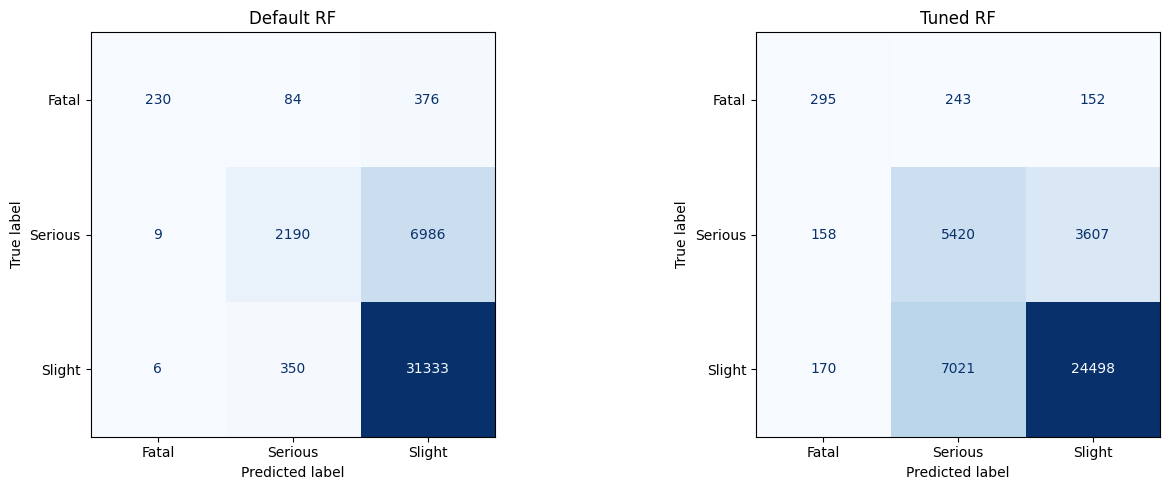

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Summary table
rf_compare = pd.DataFrame({
    "Version": ["Default RF", "Tuned RF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_default),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_rf_default),
        balanced_accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Macro-F1": [
        f1_score(y_test, y_pred_rf_default, average="macro"),
        f1_score(y_test, y_pred_rf_tuned, average="macro")
    ],
    "Weighted-F1": [
        f1_score(y_test, y_pred_rf_default, average="weighted"),
        f1_score(y_test, y_pred_rf_tuned, average="weighted")
    ]
})

display(rf_compare.round(6))

print("\nDefault RF - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_default, target_names=["Fatal", "Serious", "Slight"]))

print("\nTuned RF - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned, target_names=["Fatal", "Serious", "Slight"]))

# Raw confusion matrices
cm_default = confusion_matrix(y_test, y_pred_rf_default)
cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print("\nDefault RF - Raw Confusion Matrix:\n")
print(cm_default)

print("\nTuned RF - Raw Confusion Matrix:\n")
print(cm_tuned)

# Side-by-side plotted confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_default, display_labels=["Fatal", "Serious", "Slight"]).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Default RF")

ConfusionMatrixDisplay(cm_tuned, display_labels=["Fatal", "Serious", "Slight"]).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)
axes[1].set_title("Tuned RF")

plt.tight_layout()
plt.show()

##Conclusions till now

The two models are very close in Macro-F1 score, but the tuned RF has a much higher Balanced Accuracy. This means the decision is not obvious from Macro-F1 alone. The tuned model sacrifices a very small amount of overall macro-level F1, but it gains a substantial improvement in class-balanced recall, which is especially important for the minority severe classes.

So we will statistically compare both:

Macro-F1 difference
Balanced Accuracy difference

We compare the two models using:

paired bootstrap
95% confidence interval of the metric difference
bootstrap p-value

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, balanced_accuracy_score

def paired_bootstrap_metric_difference(y_true, y_pred_a, y_pred_b, metric_fn, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_sample = y_true[idx]
        y_a_sample = y_pred_a[idx]
        y_b_sample = y_pred_b[idx]

        score_a = metric_fn(y_true_sample, y_a_sample)
        score_b = metric_fn(y_true_sample, y_b_sample)

        diffs.append(score_b - score_a)   # Tuned RF - Default RF

    diffs = np.array(diffs)

    p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    p_value = min(p_value, 1.0)

    return {
        "mean_diff": diffs.mean(),
        "ci_low": np.percentile(diffs, 2.5),
        "ci_high": np.percentile(diffs, 97.5),
        "p_value": p_value,
        "distribution": diffs
    }

In [ ]:

y_true_np = np.array(y_test)
y_default_np = np.array(y_pred_rf_default)
y_tuned_np = np.array(y_pred_rf_tuned)

macro_result = paired_bootstrap_metric_difference(
    y_true_np,
    y_default_np,
    y_tuned_np,
    metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"),
    n_bootstrap=2000,
    random_state=42
)

balacc_result = paired_bootstrap_metric_difference(
    y_true_np,
    y_default_np,
    y_tuned_np,
    metric_fn=balanced_accuracy_score,
    n_bootstrap=2000,
    random_state=42
)

comparison_rf_df = pd.DataFrame({
    "Metric": ["Macro-F1", "Balanced Accuracy"],
    "Mean Difference (Tuned - Default)": [
        macro_result["mean_diff"],
        balacc_result["mean_diff"]
    ],
    "CI Low": [
        macro_result["ci_low"],
        balacc_result["ci_low"]
    ],
    "CI High": [
        macro_result["ci_high"],
        balacc_result["ci_high"]
    ],
    "p-value": [
        macro_result["p_value"],
        balacc_result["p_value"]
    ]
})

comparison_rf_df_pretty = comparison_rf_df.copy()

comparison_rf_df_pretty["Mean Difference (Tuned - Default)"] = comparison_rf_df_pretty["Mean Difference (Tuned - Default)"].map(lambda x: f"{x:.6f}")
comparison_rf_df_pretty["CI Low"] = comparison_rf_df_pretty["CI Low"].map(lambda x: f"{x:.6f}")
comparison_rf_df_pretty["CI High"] = comparison_rf_df_pretty["CI High"].map(lambda x: f"{x:.6f}")
comparison_rf_df_pretty["p-value"] = comparison_rf_df_pretty["p-value"].map(lambda x: f"{x:.3e}")

display(comparison_rf_df_pretty)

,Metric,Mean Difference (Tuned - Default),CI Low,CI High,p-value
0,Macro-F1,0.003238,-0.007089,0.013956,5.130e-01
1,Balanced Accuracy,0.076886,0.068524,0.085144,0.000e+00


##Final conclusion about the best model

A paired bootstrap comparison was used to compare the default and threshold-tuned Random Forest on the same test set. The results show that the threshold-tuned model did not achieve a statistically significant improvement in Macro-F1 (mean difference = 0.0032, 95% CI [-0.0071, 0.0140], p = 0.513), indicating that its overall class-balanced F1 performance was not meaningfully different from the default model. However, Balanced Accuracy improved significantly (mean difference = 0.0769, 95% CI [0.0685, 0.0851], p < 0.001), showing that the tuned model achieved substantially better average recall across classes.

Since this project gives special importance to recognizing minority severe classes, the improvement in Balanced Accuracy is important. It suggests that threshold tuning helped the model detect classes more evenly, even though this improvement was not strong enough to produce a statistically significant gain in Macro-F1. Therefore, the threshold-tuned Random Forest can still be selected as the final model if the priority is better class-wise recall and fairer treatment of minority classes, while noting clearly that the gain was significant for Balanced Accuracy but not for Macro-F1.

#Concluding the Project by checking out the top 15 most impactful factors in the tuned Random forest model

#first we see the features seen by the model

In [ ]:
import numpy as np
import pandas as pd
import os
import joblib
import gc

feature_names = list(X_train.columns)

print("Number of feature names:", len(feature_names))
print("Number of features seen by tuned RF:", rf_final_tuned.n_features_in_)

Number of feature names: 165
Number of features seen by tuned RF: 165


##shortlist highest potential candidates

In [ ]:
rf_builtin_importance = pd.DataFrame({
    "feature": feature_names,
    "rf_builtin_importance": rf_final_tuned.feature_importances_
}).sort_values("rf_builtin_importance", ascending=False).reset_index(drop=True)

display(rf_builtin_importance.head(20))

# shortlist only the most promising variables for the slower permutation step
candidate_features = rf_builtin_importance.head(40)["feature"].tolist()

print("Number of shortlisted candidate features:", len(candidate_features))

,feature,rf_builtin_importance
0,vehicles_x_casualties,0.062066
1,longitude,0.042603
2,hour,0.036770
3,age_of_vehicle,0.032355
4,month,0.030235
5,first_point_of_impact_1,0.027781
6,vehicle_manoeuvre_19,0.027683
7,driver_imd_decile,0.026540
8,urban_or_rural_area_2,0.024994
9,junction_location_1,0.023999


Number of shortlisted candidate features: 40


##we will use a smaller sample test for compute

In [ ]:
rng = np.random.default_rng(42)

sample_size = min(10000, len(y_test))   # light and safe
sample_idx = rng.choice(len(y_test), size=sample_size, replace=False)

X_test_sample = X_test_scaled.iloc[sample_idx]
y_test_sample = np.array(y_test)[sample_idx]

print("Sample size used:", len(y_test_sample))

Sample size used: 10000


##tuned prediction function

In [ ]:
from sklearn.metrics import f1_score

def tuned_rf_predict(X):
    proba = rf_final_tuned.predict_proba(X)
    preds = apply_severity_thresholds(
        proba,
        rf_final_tuned.classes_,
        t_fatal=t_fatal,
        t_serious=t_serious
    )
    return preds

##Permutation importance function

In [ ]:
def permutation_importance_tuned_rf_light(
    X,
    y,
    feature_names,
    candidate_features,
    n_repeats=5,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    X = np.array(X, copy=True)
    y = np.array(y)

    baseline_preds = tuned_rf_predict(X)
    baseline_score = f1_score(y, baseline_preds, average="macro")

    feature_to_idx = {f: i for i, f in enumerate(feature_names)}
    results = []

    for feature in candidate_features:
        j = feature_to_idx[feature]
        drops = []

        for _ in range(n_repeats):
            X_perm = X.copy()
            shuffled_col = X_perm[:, j].copy()
            rng.shuffle(shuffled_col)
            X_perm[:, j] = shuffled_col

            perm_preds = tuned_rf_predict(X_perm)
            perm_score = f1_score(y, perm_preds, average="macro")
            drops.append(baseline_score - perm_score)

        drops = np.array(drops)

        results.append({
            "feature": feature,
            "importance_mean": drops.mean(),
            "importance_std": drops.std(ddof=1) if len(drops) > 1 else 0.0,
            "ci_low": np.percentile(drops, 2.5),
            "ci_high": np.percentile(drops, 97.5)
        })

    importance_df = pd.DataFrame(results).sort_values(
        by="importance_mean",
        ascending=False
    ).reset_index(drop=True)

    return baseline_score, importance_df

##Run the functions

In [ ]:
baseline_macro_f1_tuned, tuned_importance_df = permutation_importance_tuned_rf_light(
    X=X_test_sample,
    y=y_test_sample,
    feature_names=feature_names,
    candidate_features=candidate_features,
    n_repeats=5,
    random_state=42
)

print("Baseline tuned RF Macro-F1 on sample:", round(baseline_macro_f1_tuned, 6))
display(tuned_importance_df.head(15))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Baseline tuned RF Macro-F1 on sample: 0.567629


,feature,importance_mean,importance_std,ci_low,ci_high
0,vehicles_x_casualties,0.035074,0.006676,0.025913,0.042905
1,speed_group,0.019466,0.002122,0.016366,0.021572
2,road_type_6,0.018223,0.002889,0.015684,0.022546
3,first_point_of_impact_1,0.016586,0.004066,0.010213,0.019162
4,longitude,0.014145,0.002654,0.011353,0.017686
5,hour,0.013788,0.001726,0.011815,0.016061
6,month,0.013465,0.002084,0.012064,0.016698
7,first_road_class,0.013388,0.006251,0.008760,0.023090
8,vehicle_type_9,0.012489,0.002806,0.009337,0.015269
9,vehicle_manoeuvre_19,0.012126,0.002052,0.009187,0.014246


##Save checkpoint

In [ ]:
importance_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/importance_checkpoints"
os.makedirs(importance_ckpt_dir, exist_ok=True)

joblib.dump(tuned_importance_df, f"{importance_ckpt_dir}/tuned_importance_df_light.pkl")
joblib.dump(baseline_macro_f1_tuned, f"{importance_ckpt_dir}/baseline_macro_f1_tuned_light.pkl")
joblib.dump(candidate_features, f"{importance_ckpt_dir}/candidate_features_light.pkl")

print("Light importance checkpoint saved.")
print("Saved to:", importance_ckpt_dir)

Light importance checkpoint saved.
Saved to: /content/drive/MyDrive/CMPS 262 Project/importance_checkpoints


##Load checkpoint

In [ ]:
importance_ckpt_dir = "/content/drive/MyDrive/CMPS 262 Project/importance_checkpoints"

tuned_importance_df = joblib.load(f"{importance_ckpt_dir}/tuned_importance_df_light.pkl")
baseline_macro_f1_tuned = joblib.load(f"{importance_ckpt_dir}/baseline_macro_f1_tuned_light.pkl")
candidate_features = joblib.load(f"{importance_ckpt_dir}/candidate_features_light.pkl")

print("Light importance checkpoint loaded.")
display(tuned_importance_df.head(15))

#Conclusion about which variables contributed the most to collision type

Permutation importance on the tuned Random Forest shows that collision severity was influenced mainly by a combination of number of vehicles involved, speed-related factors, road type, collision structure, location, and time.

The most important variable was vehicles_x_casualties, which suggests that the scale of the collision was strongly related to severity. Speed_group and speed_x_urban were also important, showing that speed conditions played a major role in distinguishing more severe collisions. In addition, road_type_6, road_type_3, and first_road_class indicate that the road environment itself contributed meaningfully to severity prediction.

The model also assigned notable importance to first_point_of_impact_1, which suggests that how the collision begins or where the impact occurs matters for the final severity outcome. Longitude was among the important variables as well, meaning that location patterns were associated with severity, likely capturing differences between areas rather than acting as a direct cause.

Finally, hour and month were important, showing that collision severity also varied across time. Overall, the model suggests that severity is not explained by one factor alone, but by a mix of collision scale, speed context, road setting, impact structure, location, and timing.

#Advice to the UK government based on our results

The results suggest that the UK government should move toward a targeted severity-risk strategy rather than relying only on broad road-safety measures. Since the most important variables were linked to speed conditions, road type, collision structure, location, and time, interventions should focus on the combinations of these factors where severe collisions are more likely.

In practice, this means giving special attention to higher-risk road types and road classes, strengthening speed control measures, and identifying locations where severe outcomes appear more frequently. Because hour and month were also important, enforcement and prevention efforts should be concentrated during the times when severe collisions are more likely, instead of being spread evenly across all periods.

Overall, the findings support using the model to identify higher-risk contexts and directing road-safety action toward those specific conditions.